In [144]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from pathlib import Path
from vizman import viz
import os
import pickle

print(os.getcwd())

from config import (
    COLORS, COLOR_SCHEME, LABEL_MAP, gray_cmap, bone_white, half_black,
    emp_dataset_and_experiment_pairs, PROPERTY_NAMES, REPRESENTATIVES_FOR_GOALS,
)

%load_ext autoreload
%autoreload 2

/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/B_pca_and_pareto_trade-off
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Section 1 — All Properties (Exploratory)

In [ ]:
data_folder = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis")
# all_datasets_precise_categories
with open(data_folder / "all_datasets_filtered.pkl", "rb") as f:
    dict_with_all_datasets = pickle.load(f)

In [146]:
# Concatenate all datasets into one DataFrame.
# NOTE: kaysons_generated_networks_topology is excluded because its networks
# are parameterised differently (no eta/gamma/etc.), making them incompatible
# with the rest of the concatenated feature space.

SKIP_DATASETS = {"kaysons_generated_networks_topology"}

huge_df = pd.DataFrame()
for dataset_name, df in dict_with_all_datasets.items():
    print(f"{dataset_name}: {len(df)} rows")

    if dataset_name in SKIP_DATASETS:
        print("  --> skipped")
        continue

    # .copy() prevents mutating the original dict entries
    df = df.copy()
    df["dataset"] = dataset_name
    huge_df = pd.concat([huge_df, df], ignore_index=True)

# Drop rows that are entirely NaN
huge_df.dropna(how="all", inplace=True)
print(f"\nFinal shape: {huge_df.shape}")

hcp_schaefer_100_dataset_gnm: 25000 rows
hcp_schaefer_100_dataset: 100 rows
kaysons_generated_networks_diffusion: 1 rows
kaysons_generated_networks_propagation: 1 rows
kaysons_generated_networks_routing: 1 rows
kaysons_generated_networks_topology: 2 rows
  --> skipped
suarez_MaMI_dataset: 224 rows

Final shape: (25327, 175)


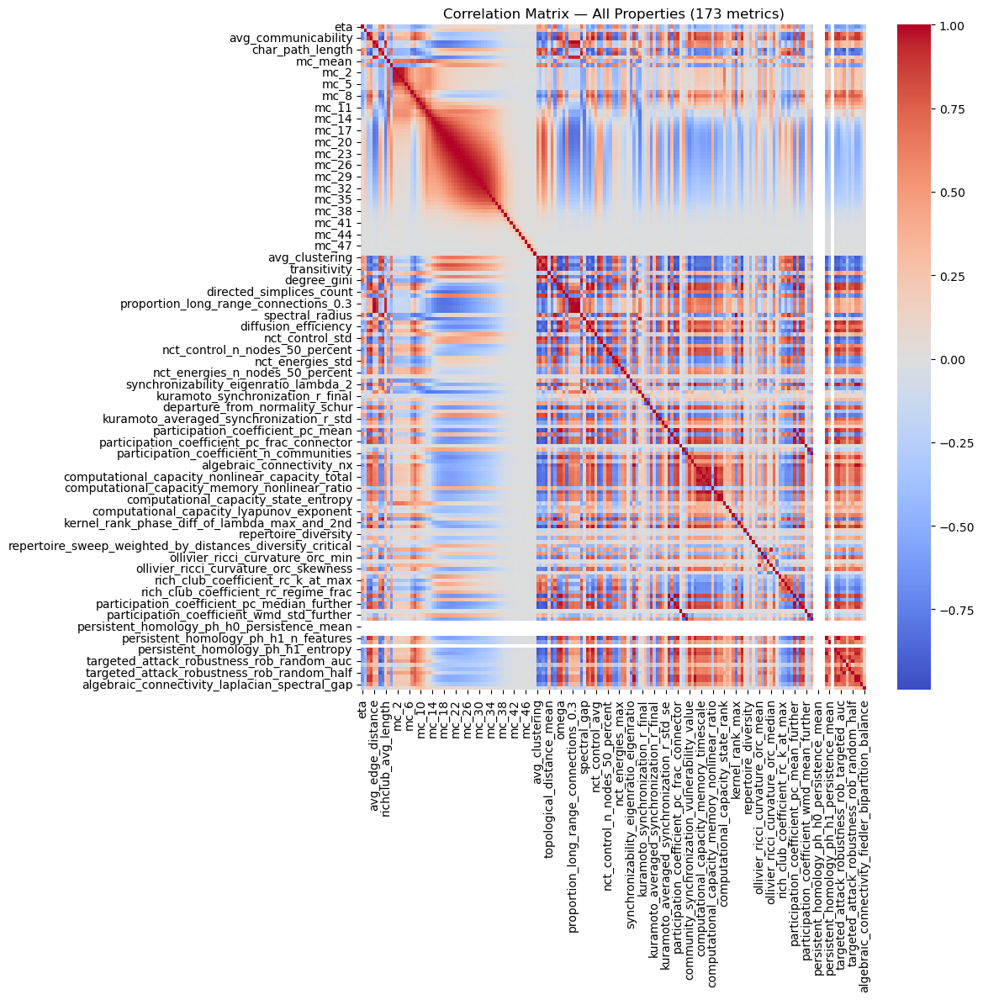

In [147]:
# Drop non-numeric / identifier columns before computing correlations.
# The 'dataset' check is not needed here — we just dropped it explicitly.
all_df_props = huge_df.drop(columns=[c for c in ["dataset", "id"] if c in huge_df.columns])

corr_all = all_df_props.corr()

plt.figure(figsize=(12, 12))
sns.heatmap(corr_all, annot=False, cmap="coolwarm", cbar=True)
plt.title(f"Correlation Matrix — All Properties ({corr_all.shape[0]} metrics)")
plt.tight_layout()
plt.show()

Dropped 2 columns with NaN/inf: ['repertoire_size', 'repertoire_diversity']


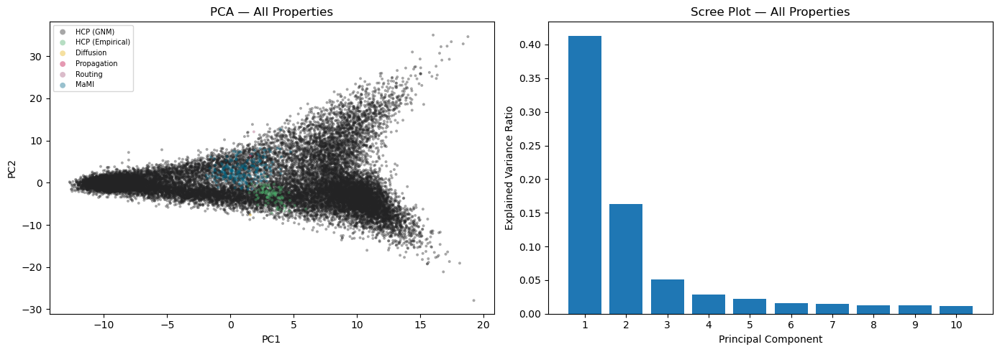

In [148]:
# ── Clean data: replace inf → NaN *first*, then detect and drop bad columns ──
# (Ordering matters: if inf→NaN comes after isnull(), we miss inf-induced NaNs)
all_df_props_clean = all_df_props.replace([np.inf, -np.inf], np.nan)
dropped_all = all_df_props_clean.columns[all_df_props_clean.isnull().any()].tolist()
all_df_props_clean = all_df_props_clean.dropna(axis=1)
print(f"Dropped {len(dropped_all)} columns with NaN/inf: {dropped_all}")

all_scaler = StandardScaler()
all_scaled = all_scaler.fit_transform(all_df_props_clean)

all_pca = PCA(n_components=10)
all_pca_result = all_pca.fit_transform(all_scaled)

# ── Scatter: PC1 vs PC2 ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for ds in huge_df["dataset"].unique():
    mask = (huge_df["dataset"] == ds).values
    ax.scatter(all_pca_result[mask, 0], all_pca_result[mask, 1],
               c=COLOR_SCHEME[ds], label=LABEL_MAP.get(ds, ds), alpha=0.4, s=8, edgecolors="none")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA — All Properties")
ax.legend(markerscale=2, fontsize=7)

# ── Scree plot ────────────────────────────────────────────────────────────────
ax = axes[1]
ev = all_pca.explained_variance_ratio_
ax.bar(range(1, len(ev) + 1), ev)
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance Ratio")
ax.set_title("Scree Plot — All Properties")
ax.set_xticks(range(1, len(ev) + 1))

plt.tight_layout()
plt.show()

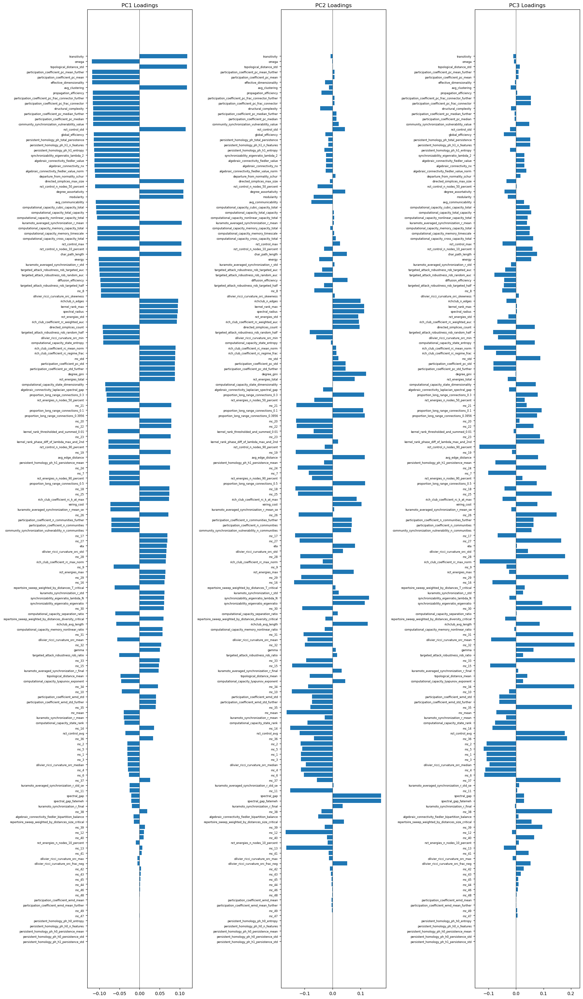

In [149]:
# Show loadings for the first 3 PCs, sorted by |PC1 loading| (ascending,
# so the largest contributors are at the top of the horizontal bar chart).
all_loadings = all_pca.components_.T               # shape: (n_features, n_components)
sort_idx = np.argsort(np.abs(all_loadings[:, 0]))  # ascending → largest at top in barh
all_loadings_sorted  = all_loadings[sort_idx]
all_metric_names_sorted = all_df_props_clean.columns[sort_idx]

fig, axs = plt.subplots(1, 3, figsize=(18, max(6, len(all_metric_names_sorted) * 0.18)), dpi=100)
for i in range(3):
    axs[i].barh(range(len(all_metric_names_sorted)), all_loadings_sorted[:, i])
    axs[i].set_yticks(range(len(all_metric_names_sorted)))
    axs[i].set_yticklabels(all_metric_names_sorted, fontsize=6)
    axs[i].set_title(f"PC{i+1} Loadings")
    axs[i].axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

# Section 2 — Selected Properties (Main Analysis)

Variables are prefixed `sel_` throughout to avoid colliding with Section 1.


In [150]:
# This pickle was produced by a prior processing step that assembles the
# curated feature matrix (matching huge_df rows + dataset label).
input_folder  = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis")
output_folder = input_folder / "pca_results"
output_folder.mkdir(exist_ok=True)

with open(input_folder / "pca_input_df.pkl", "rb") as f:
    pca_input_df_label = pickle.load(f)   # includes a 'dataset' column

# Drop GNM-specific model parameters that are undefined for empirical networks
cols_to_drop = ["eta", "gamma", "mc_15", "wiring_cost"]
sel_df_label = pca_input_df_label.drop(
    columns=[c for c in cols_to_drop if c in pca_input_df_label.columns]
)

print(f"Loaded: {sel_df_label.shape[0]} networks × {sel_df_label.shape[1]-1} features")
print(f"Datasets: {sel_df_label['dataset'].value_counts().to_dict()}")

Loaded: 25327 networks × 73 features
Datasets: {'hcp_schaefer_100_dataset_gnm': 25000, 'suarez_MaMI_dataset': 224, 'hcp_schaefer_100_dataset': 100, 'kaysons_generated_networks_diffusion': 1, 'kaysons_generated_networks_propagation': 1, 'kaysons_generated_networks_routing': 1}


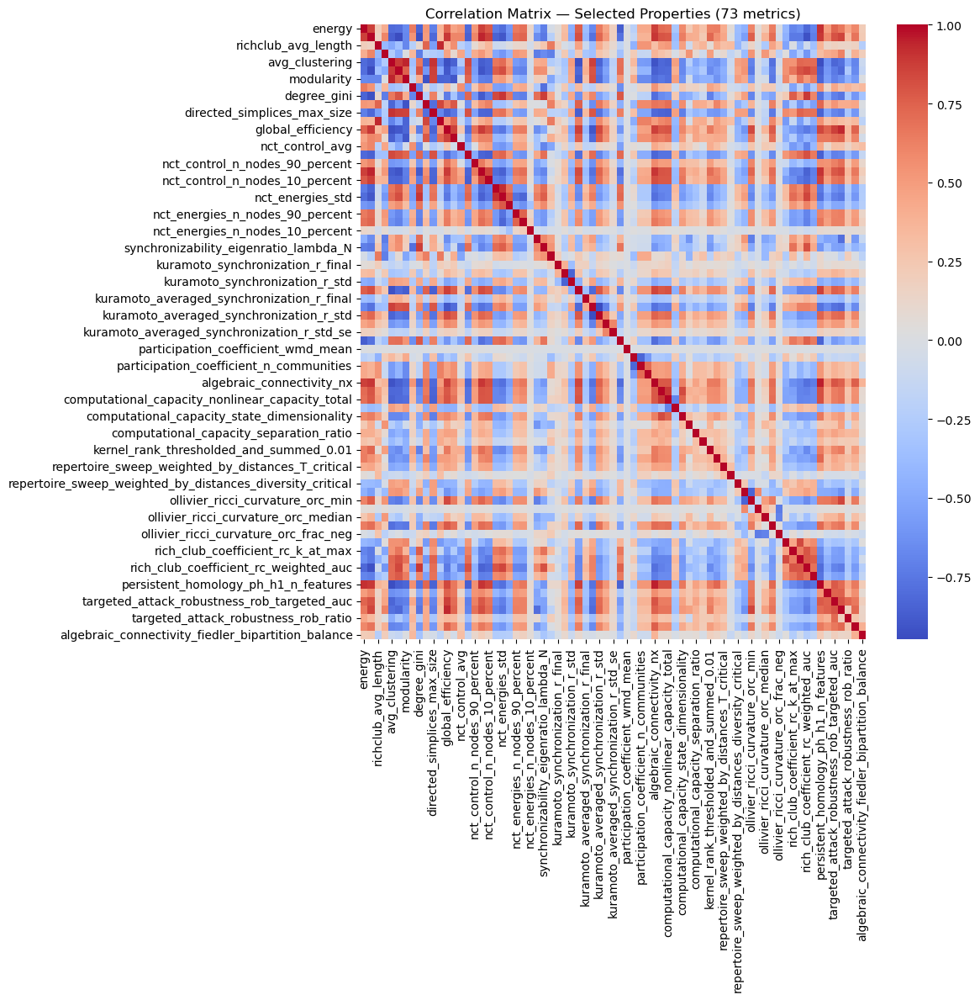

In [151]:
sel_df = sel_df_label.drop(columns="dataset")

corr_sel = sel_df.corr()

plt.figure(figsize=(12, 12))
sns.heatmap(corr_sel, annot=False, cmap="coolwarm", cbar=True)
plt.title(f"Correlation Matrix — Selected Properties ({corr_sel.shape[0]} metrics)")
plt.tight_layout()
plt.show()

In [152]:
# # ── Optional: category-ordered heatmap (requires metadata Excel) ─────────────
# # Set excel_path to None to skip this cell.
# excel_path = "/Users/adrian/Desktop/network_properties_full_excel.xlsx"

# if excel_path is None:
#     print("Skipping category-ordered heatmap (no Excel path provided).")
# else:
#     meta_raw = pd.read_excel(excel_path, sheet_name=0)

#     # Forward-fill section headers
#     meta_raw["section"] = meta_raw.apply(
#         lambda r: r["#"] if pd.isna(r["Variable Name"]) and pd.notna(r["#"]) else None,
#         axis=1,
#     ).ffill()

#     meta = (
#         meta_raw[meta_raw["Variable Name"].notna()]
#         [["Variable Name", "Category", "Integ/Segr/Rob", "section"]]
#         .rename(columns={"Variable Name": "var"})
#         .set_index("var")
#     )

#     # ── Build column ordering by Integration/Segregation/Robustness ───────────
#     CLASS_COL      = "Integ/Segr/Rob"
#     UNCLASSIFIED   = "—"
#     CLASS_ORDER    = ["Integration", "Segregation", "Robustness", UNCLASSIFIED]
#     CLASS_COLOURS  = {
#         "Integration": "#4C72B0", "Segregation": "#DD8452",
#         "Robustness":  "#55A868", UNCLASSIFIED:  "#AAAAAA",
#     }

#     cols_in_data = [c for c in sel_df.columns if c in meta.index]

#     def get_class(col):
#         v = meta.loc[col, CLASS_COL]
#         return v if pd.notna(v) else UNCLASSIFIED

#     cols_sorted = sorted(
#         cols_in_data,
#         key=lambda c: (
#             CLASS_ORDER.index(get_class(c)) if get_class(c) in CLASS_ORDER else len(CLASS_ORDER),
#             str(meta.loc[c, "section"]),
#         ),
#     )

#     # Within-group hierarchical clustering
#     corr_full = sel_df[cols_in_data].corr()
#     final_order = []
#     for cls in CLASS_ORDER:
#         cls_cols = [c for c in cols_sorted if get_class(c) == cls]
#         if len(cls_cols) <= 1:
#             final_order.extend(cls_cols)
#             continue
#         sub_corr = corr_full.loc[cls_cols, cls_cols].fillna(0)
#         dist     = np.clip(1 - sub_corr.values, 0, 2)
#         np.fill_diagonal(dist, 0)
#         Z     = linkage(squareform(dist, checks=False), method="average")
#         order = leaves_list(Z)
#         final_order.extend([cls_cols[i] for i in order])
#     # Append any uncategorised variables at the end
#     final_order.extend([c for c in cols_in_data if c not in final_order])

#     # ── Draw heatmap ──────────────────────────────────────────────────────────
#     red_corr = corr_full.loc[final_order, final_order]
#     n = len(final_order)

#     fig = plt.figure(figsize=(14, 12))
#     gs  = gridspec.GridSpec(
#         2, 2, width_ratios=[0.04, 1], height_ratios=[0.04, 1],
#         hspace=0.01, wspace=0.01,
#     )
#     ax_row_bar = fig.add_subplot(gs[1, 0])
#     ax_col_bar = fig.add_subplot(gs[0, 1])
#     ax_heat    = fig.add_subplot(gs[1, 1])

#     row_colors = [CLASS_COLOURS[get_class(c)] for c in final_order]
#     ax_row_bar.imshow([[c] for c in row_colors], aspect="auto",
#                       extent=[0, 1, -0.5, n - 0.5], origin="lower")
#     ax_col_bar.imshow([row_colors], aspect="auto",
#                       extent=[-0.5, n - 0.5, 0, 1], origin="lower")
#     for bar_ax in (ax_row_bar, ax_col_bar):
#         bar_ax.set_xticks([])
#         bar_ax.set_yticks([])

#     img = ax_heat.imshow(red_corr.values, cmap="coolwarm", vmin=-1, vmax=1,
#                          aspect="auto", origin="lower")
#     ax_heat.set_xticks([])
#     ax_heat.set_yticks([])

#     legend_patches = [
#         mpatches.Patch(color=v, label=k) for k, v in CLASS_COLOURS.items()
#         if any(get_class(c) == k for c in final_order)
#     ]
#     ax_heat.legend(handles=legend_patches, loc="upper right",
#                    bbox_to_anchor=(1.25, 1.05), fontsize=8)

#     cbar = fig.colorbar(img, ax=ax_heat, fraction=0.03, pad=0.01)
#     cbar.set_label("Pearson r", fontsize=9)
#     ax_heat.set_title(
#         f"Correlation Matrix — {n} metrics  (ordered by Integ/Segr/Rob)",
#         fontsize=11, pad=8,
#     )
#     plt.savefig(output_folder / "corr_matrix_integsegrob.pdf", dpi=150, bbox_inches="tight")
#     plt.show()
#     print("Saved: corr_matrix_integsegrob.pdf")

Dropped 0 columns with NaN/inf: []
Remaining: 73 features, 25327 networks


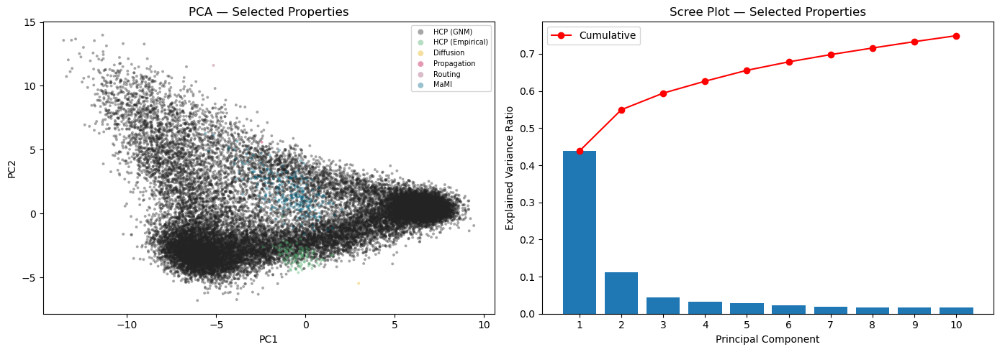

In [153]:
# ── Replace inf → NaN first, then detect bad columns (ordering matters!) ─────
sel_df_clean = sel_df.replace([np.inf, -np.inf], np.nan)
dropped_sel  = sel_df_clean.columns[sel_df_clean.isnull().any()].tolist()
sel_df_clean = sel_df_clean.dropna(axis=1)
print(f"Dropped {len(dropped_sel)} columns with NaN/inf: {dropped_sel}")
print(f"Remaining: {sel_df_clean.shape[1]} features, {sel_df_clean.shape[0]} networks")

sel_scaler = StandardScaler()
sel_scaled = sel_scaler.fit_transform(sel_df_clean)

sel_pca = PCA(n_components=10)
sel_pca_result = sel_pca.fit_transform(sel_scaled)

# ── Scatter: PC1 vs PC2 ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for ds in sel_df_label["dataset"].unique():
    mask = (sel_df_label["dataset"] == ds).values
    ax.scatter(sel_pca_result[mask, 0], sel_pca_result[mask, 1],
               c=COLOR_SCHEME[ds], label=LABEL_MAP.get(ds, ds),
               alpha=0.4, s=8, edgecolors="none")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA — Selected Properties")
ax.legend(markerscale=2, fontsize=7)

# ── Scree plot ────────────────────────────────────────────────────────────────
ax = axes[1]
ev = sel_pca.explained_variance_ratio_
ax.bar(range(1, len(ev) + 1), ev)
ax.plot(range(1, len(ev) + 1), np.cumsum(ev), marker="o", color="red",
        label="Cumulative")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance Ratio")
ax.set_title("Scree Plot — Selected Properties")
ax.set_xticks(range(1, len(ev) + 1))
ax.legend()

plt.tight_layout()
plt.show()

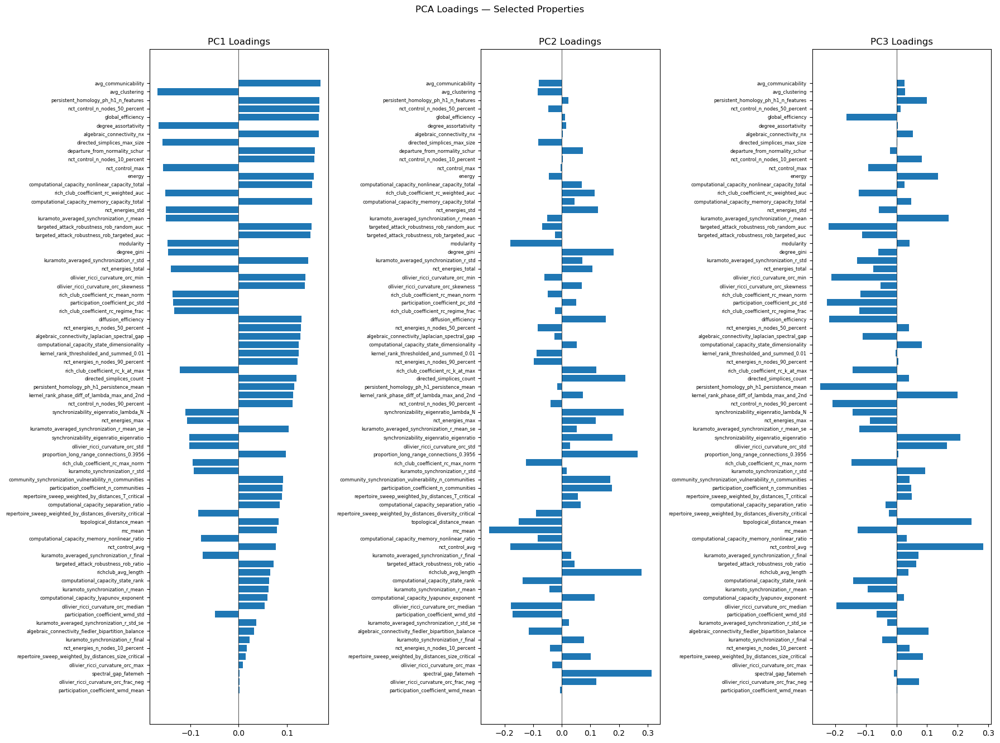

Top 10 features by PC1+PC2 loading magnitude:
  spectral_gap_fatemeh: 0.3144
  richclub_avg_length: 0.2856
  proportion_long_range_connections_0.3956: 0.2824
  mc_mean: 0.2664
  directed_simplices_count: 0.2529
  synchronizability_eigenratio_lambda_N: 0.2438
  degree_gini: 0.2333
  modularity: 0.2327
  synchronizability_eigenratio_eigenratio: 0.2041
  diffusion_efficiency: 0.2016


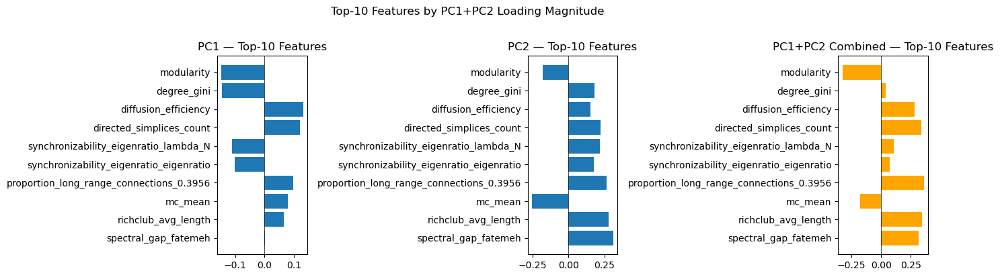

In [154]:
# ── Loadings: all features, sorted by |PC1 loading| ─────────────────────────
sel_loadings     = sel_pca.components_.T          # (n_features, n_components)
sel_metric_names = sel_df_clean.columns

sort_idx_pc1 = np.argsort(np.abs(sel_loadings[:, 0]))   # ascending → top at top in barh
sel_loadings_sorted_pc1     = sel_loadings[sort_idx_pc1]
sel_metric_names_sorted_pc1 = sel_metric_names[sort_idx_pc1]

fig, axs = plt.subplots(1, 3, figsize=(18, max(6, len(sel_metric_names) * 0.18)), dpi=100)
for i in range(3):
    axs[i].barh(range(len(sel_metric_names)), sel_loadings_sorted_pc1[:, i])
    axs[i].set_yticks(range(len(sel_metric_names)))
    axs[i].set_yticklabels(sel_metric_names_sorted_pc1, fontsize=6)
    axs[i].set_title(f"PC{i+1} Loadings")
    axs[i].axvline(0, color="black", linewidth=0.5)
plt.suptitle("PCA Loadings — Selected Properties", y=1.01)
plt.tight_layout()
plt.show()

# ── Top-10 by combined PC1+PC2 loading magnitude ─────────────────────────────
# Correct: sort by sqrt(PC1² + PC2²), take the 10 LARGEST
combined_magnitude = np.sqrt(sel_loadings[:, 0]**2 + sel_loadings[:, 1]**2)
top10_idx      = np.argsort(combined_magnitude)[::-1][:10]   # [::-1] → descending
top10_names    = sel_metric_names[top10_idx]
top10_loadings = sel_loadings[top10_idx]

# Sort ascending for barh display (largest at top)
disp_order = np.argsort(np.abs(top10_loadings[:, 0]))
top10_names_disp    = top10_names[disp_order]
top10_loadings_disp = top10_loadings[disp_order]

print("Top 10 features by PC1+PC2 loading magnitude:")
for name, mag in zip(top10_names, combined_magnitude[top10_idx]):
    print(f"  {name}: {mag:.4f}")

fig, axs = plt.subplots(1, 3, figsize=(14, 4), dpi=100)
for i in range(2):
    axs[i].barh(range(10), top10_loadings_disp[:, i])
    axs[i].set_yticks(range(10))
    axs[i].set_yticklabels(top10_names_disp)
    axs[i].set_title(f"PC{i+1} — Top-10 Features")
    axs[i].axvline(0, color="black", linewidth=0.5)

# Third panel: PC1+PC2 combined loading
combined_disp = top10_loadings_disp[:, 0] + top10_loadings_disp[:, 1]
axs[2].barh(range(10), combined_disp, color="orange")
axs[2].set_yticks(range(10))
axs[2].set_yticklabels(top10_names_disp)
axs[2].set_title("PC1+PC2 Combined — Top-10 Features")
axs[2].axvline(0, color="black", linewidth=0.5)

plt.suptitle("Top-10 Features by PC1+PC2 Loading Magnitude", y=1.02)
plt.tight_layout()
plt.show()

## Corner Point Analysis

In [ ]:
# ── Helper: spider plot ───────────────────────────────────────────────────────
def make_spider(ax, values, label, color, axis_labels, title=None):
    """Draw a single radar/spider plot on a polar axis."""
    n = len(axis_labels)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles += angles[:1]
    vals = list(values) + [values[0]]
    ax.plot(angles, vals, color=color, linewidth=2, label=label)
    ax.fill(angles, vals, color=color, alpha=0.15)
    ax.set_thetagrids(np.degrees(angles[:-1]), axis_labels, fontsize=7)
    ax.tick_params(pad=6)
    if title:
        ax.set_title(title, fontsize=9, pad=14)


# ── Shared spider axis labels: predefined goal representatives ────────────────
# (Defined here so it's clear and not accidentally overriding the config import)
GOAL_REPRESENTATIVES = {
    "proportion_long_range_connections_0.3956":                 "Wiring\nEconomy",
    
    "modularity":                                               "Segregation",
    
    "computational_capacity_nonlinear_capacity_total":          "Capacity\n(Nonlinear)",
    "mc_mean":                                                  "Capacity\n(Memory)",
    # NCT control? 
    "nct_control_avg":                                          "Control\n(NCT)",
    
    "global_efficiency":                                        "Integration",
    
    "targeted_attack_robustness_rob_targeted_auc":              "Robustness\n(Targeted)",
    "algebraic_connectivity_nx":                                "Robustness", # lambda_2
    
    # "synchronizability_eigenratio_eigenratio":                  "Synchroniz-\nability",
    
    "kuramoto_synchronization_r_std":                            "Metastability",
    "repertoire_sweep_weighted_by_distances_diversity_critical": "Repertoire\nDiversity",
    
}
rep_keys   = list(GOAL_REPRESENTATIVES.keys())
rep_labels = list(GOAL_REPRESENTATIVES.values())
rep_idx    = [sel_df_clean.columns.get_loc(k) for k in rep_keys]

# ── Angles for spider (shared across all spider plots) ───────────────────────
n_axes   = len(rep_labels)
angles   = np.linspace(0, 2 * np.pi, n_axes, endpoint=False).tolist()
angles  += angles[:1]


# ── Corner point definitions ──────────────────────────────────────────────────
CORNER_COLORS = {
    "top_left":     "steelblue",
    "bottom_left":  "orange",
    "bottom_right": "forestgreen",
}

def find_corners(pca_result_2d):
    """Return a dict of corner name → row index within pca_result_2d."""
    return {
        "top_left":     int(np.argmax( pca_result_2d[:, 1])),
        "bottom_left":  int(np.argmax(-pca_result_2d[:, 0] - pca_result_2d[:, 1])),
        "bottom_right": int(np.argmax( pca_result_2d[:, 0] - pca_result_2d[:, 1])),
    }

Corner points (full dataset):
  top_left: idx=11126, PC1=-11.37, PC2=13.97, dataset=hcp_schaefer_100_dataset_gnm
  bottom_left: idx=2031, PC1=-9.63, PC2=-3.50, dataset=hcp_schaefer_100_dataset_gnm
  bottom_right: idx=8358, PC1=9.17, PC2=-1.34, dataset=hcp_schaefer_100_dataset_gnm


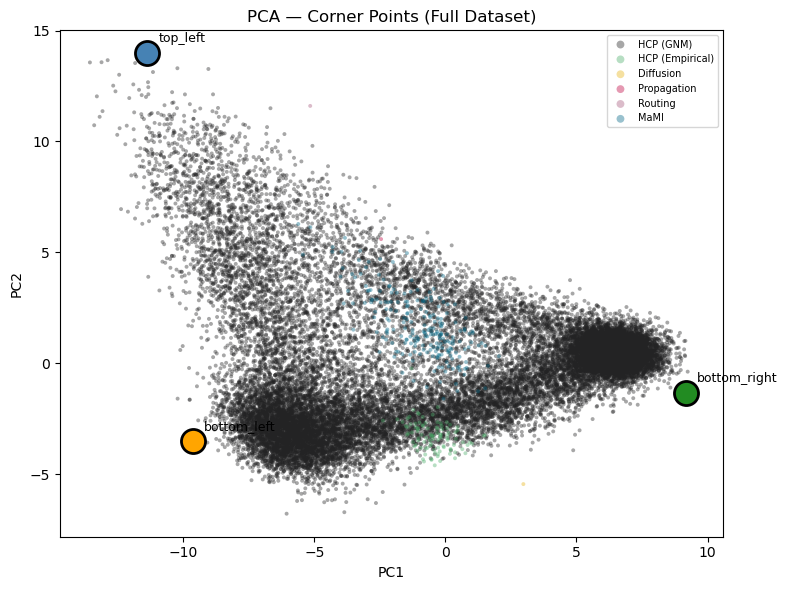

In [172]:
# ── Corners in the full selected-properties PCA space ────────────────────────
corners_full = find_corners(sel_pca_result)

print("Corner points (full dataset):")
for name, idx in corners_full.items():
    ds = sel_df_label["dataset"].iloc[idx]
    print(f"  {name}: idx={idx}, PC1={sel_pca_result[idx,0]:.2f}, PC2={sel_pca_result[idx,1]:.2f}, dataset={ds}")

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
for ds in sel_df_label["dataset"].unique():
    mask = (sel_df_label["dataset"] == ds).values
    ax.scatter(sel_pca_result[mask, 0], sel_pca_result[mask, 1],
               c=COLOR_SCHEME[ds], label=LABEL_MAP.get(ds, ds),
               alpha=0.4, s=8, edgecolors="none")
for name, idx in corners_full.items():
    ax.scatter(sel_pca_result[idx, 0], sel_pca_result[idx, 1],
               s=300, zorder=5, edgecolors="black", linewidths=2,
               color=CORNER_COLORS[name])
    ax.annotate(name, (sel_pca_result[idx, 0], sel_pca_result[idx, 1]),
                textcoords="offset points", xytext=(8, 8), fontsize=9)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA — Corner Points (Full Dataset)")
ax.legend(markerscale=2, fontsize=7)
plt.tight_layout()
plt.show()

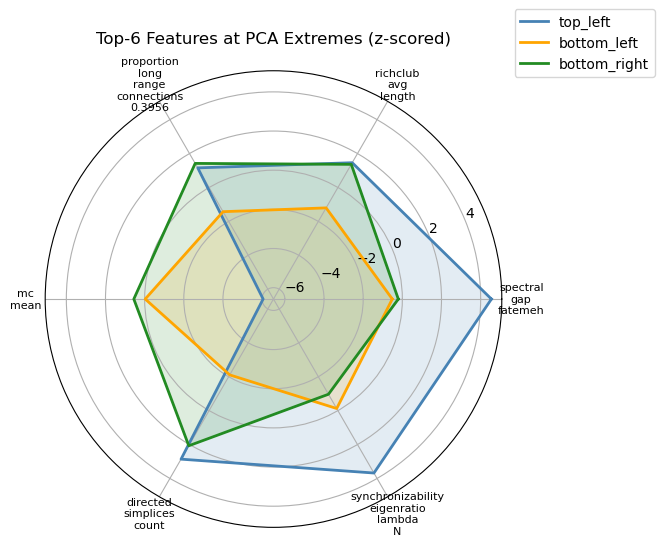

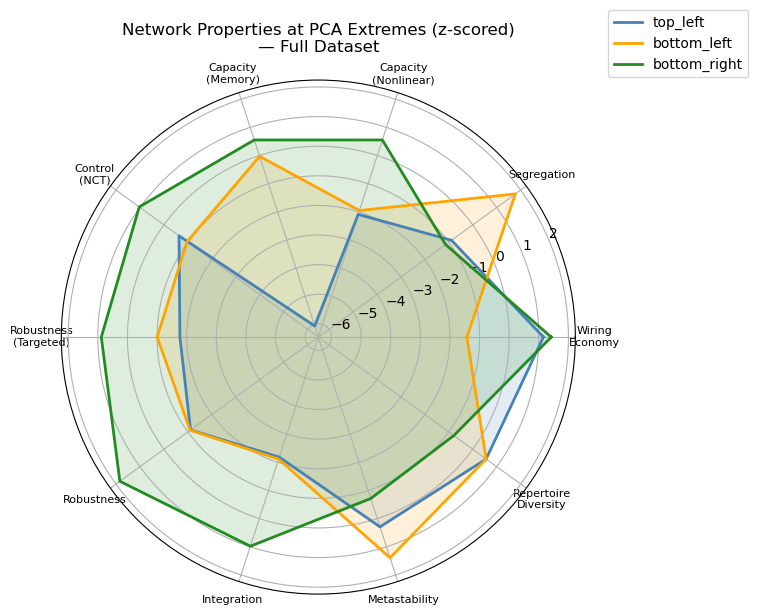

In [173]:
# ── Spider plot for the top-6 features by PC1+PC2 loading magnitude ──────────
top6_idx = np.argsort(np.sqrt(sel_loadings[:, 0]**2 + sel_loadings[:, 1]**2))[::-1][:6]
top6_names  = sel_metric_names[top6_idx]
top6_labels = [n.replace("_", "\n") for n in top6_names]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for name, idx in corners_full.items():
    vals = list(sel_scaled[idx, top6_idx]) + [sel_scaled[idx, top6_idx[0]]]
    a    = np.linspace(0, 2*np.pi, 6, endpoint=False).tolist() + [0]
    ax.plot(a, vals, color=CORNER_COLORS[name], linewidth=2, label=name)
    ax.fill(a, vals, color=CORNER_COLORS[name], alpha=0.15)
ax.set_thetagrids(np.degrees(np.linspace(0, 2*np.pi, 6, endpoint=False)), top6_labels, fontsize=8)
ax.set_title("Top-6 Features at PCA Extremes (z-scored)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15))
plt.tight_layout()
plt.show()

# ── Spider plot using predefined goal representatives ─────────────────────────
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for name, idx in corners_full.items():
    vals = list(sel_scaled[idx, rep_idx]) + [sel_scaled[idx, rep_idx[0]]]
    ax.plot(angles, vals, color=CORNER_COLORS[name], linewidth=2, label=name)
    ax.fill(angles, vals, color=CORNER_COLORS[name], alpha=0.15)
ax.set_thetagrids(np.degrees(angles[:-1]), rep_labels, fontsize=8)
ax.set_title("Network Properties at PCA Extremes (z-scored)\n— Full Dataset", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15))
plt.tight_layout()
plt.show()

## Corner Analysis — Excluding GNM Dataset

The GNM dataset dominates the PCA space (25,000 synthetic networks vs ~350 empirical/optimised ones).
Corners found here are more representative of the empirical and optimal-network space.

**Important**: corner indices are found within the filtered (no-GNM) view, then **remapped** back
to their original positions in `sel_scaled` before extracting feature values.
Skipping this remapping is a common index-aliasing bug.


In [174]:
sel_df_label["dataset"].unique()

array(['hcp_schaefer_100_dataset_gnm', 'hcp_schaefer_100_dataset',
       'kaysons_generated_networks_diffusion',
       'kaysons_generated_networks_propagation',
       'kaysons_generated_networks_routing', 'suarez_MaMI_dataset'],
      dtype=object)

Corner points (no-GNM):
  top_left: filtered_idx=171, original_idx=25174, PC1=-5.61, PC2=6.28, dataset=suarez_MaMI_dataset
  bottom_left: filtered_idx=67, original_idx=25067, PC1=-0.82, PC2=-4.43, dataset=hcp_schaefer_100_dataset
  bottom_right: filtered_idx=7, original_idx=25007, PC1=0.76, PC2=-4.06, dataset=hcp_schaefer_100_dataset


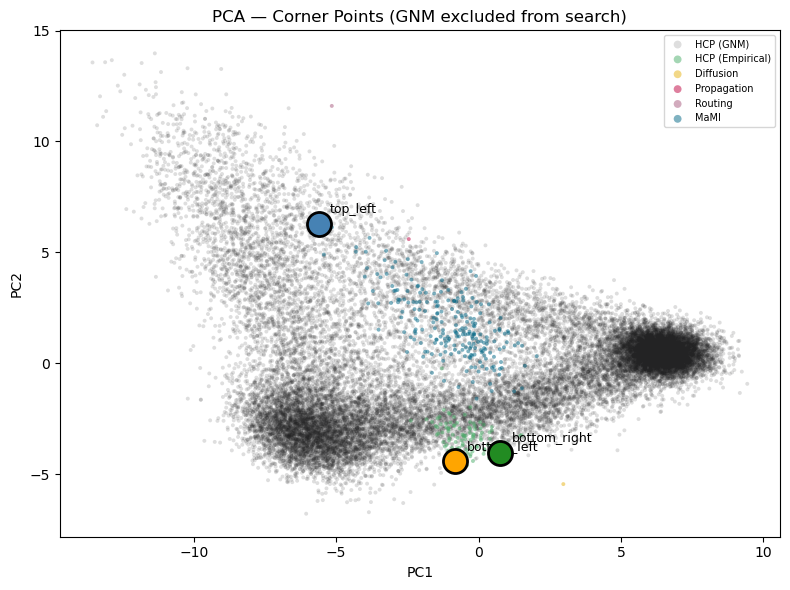

In [175]:
GNM_DATASET = "hcp_schaefer_100_dataset_gnm"

# Boolean mask & original indices of non-GNM rows
# no_gnm_mask          = (sel_df_label["dataset"] != GNM_DATASET).values
# no_gnm_original_idx  = np.where(no_gnm_mask)[0]        # positions in sel_scaled / sel_pca_result
# mask = no_gnm_mask
# orig_idx = no_gnm_original_idx

# Only get datasets that are mami or hcp 
mask = (sel_df_label["dataset"] == "hcp_schaefer_100_dataset").values | (sel_df_label["dataset"] == "suarez_MaMI_dataset").values
orig_idx = np.where(mask)[0]        # positions in sel_scaled / sel_pca_result

# PCA results restricted to non-GNM networks
sel_pca_result_no_gnm = sel_pca_result[mask]

# Find corners inside the filtered view (0-indexed within the subset)
corners_no_gnm_filtered = find_corners(sel_pca_result_no_gnm)

# ── Remap to original row indices for sel_scaled ──────────────────────────────
# Without this step, e.g. filtered_idx=5 would incorrectly retrieve row 5 of
# sel_scaled (a GNM network), not the 5th non-GNM network.
corners_no_gnm = {
    name: int(orig_idx[filt_idx])
    for name, filt_idx in corners_no_gnm_filtered.items()
}

print("Corner points (no-GNM):")
for name, orig_idx in corners_no_gnm.items():
    ds = sel_df_label["dataset"].iloc[orig_idx]
    filt_idx = corners_no_gnm_filtered[name]
    print(f"  {name}: filtered_idx={filt_idx}, original_idx={orig_idx}, "
          f"PC1={sel_pca_result[orig_idx,0]:.2f}, PC2={sel_pca_result[orig_idx,1]:.2f}, dataset={ds}")

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

# Background: all datasets (GNM faded)
for ds in sel_df_label["dataset"].unique():
    mask_ds = (sel_df_label["dataset"] == ds).values
    alpha = 0.15 if ds == GNM_DATASET else 0.5
    ax.scatter(sel_pca_result[mask_ds, 0], sel_pca_result[mask_ds, 1],
               c=COLOR_SCHEME[ds], label=LABEL_MAP.get(ds, ds),
               alpha=alpha, s=8, edgecolors="none")

# Corner markers (using original indices so they are in the correct location)
for name, orig_idx in corners_no_gnm.items():
    ax.scatter(sel_pca_result[orig_idx, 0], sel_pca_result[orig_idx, 1],
               s=300, zorder=5, edgecolors="black", linewidths=2,
               color=CORNER_COLORS[name])
    ax.annotate(name, (sel_pca_result[orig_idx, 0], sel_pca_result[orig_idx, 1]),
                textcoords="offset points", xytext=(8, 8), fontsize=9)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA — Corner Points (GNM excluded from search)")
ax.legend(markerscale=2, fontsize=7)
plt.tight_layout()
plt.show()

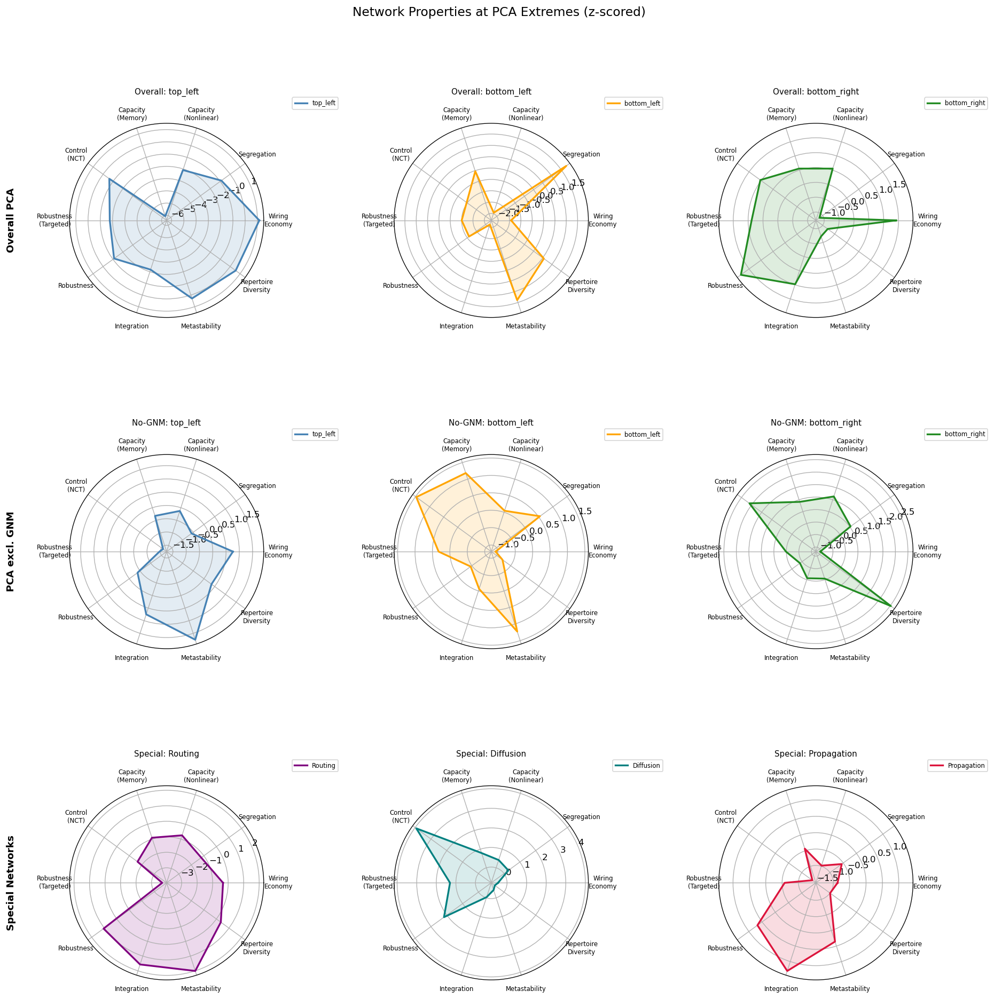

Saved: spider_multipanel.pdf


In [176]:
SPECIAL_DATASETS = {
    "kaysons_generated_networks_routing":     ("Routing",     "purple"),
    "kaysons_generated_networks_diffusion":   ("Diffusion",   "teal"),
    "kaysons_generated_networks_propagation": ("Propagation", "crimson"),
}

# Original row index for single-network datasets
special_indices = {
    ds: int(sel_df_label.index[sel_df_label["dataset"] == ds][0])
    for ds in SPECIAL_DATASETS
}

# ── Build 3 × 3 figure ────────────────────────────────────────────────────────
fig, axs = plt.subplots(3, 3, figsize=(16, 16), subplot_kw=dict(polar=True), dpi=120)

row_configs = [
    # (title prefix, corners_dict or special list, use_corners_colors)
    ("Overall",   list(corners_full.items()),    CORNER_COLORS),
    ("No-GNM",    list(corners_no_gnm.items()),  CORNER_COLORS),
    ("Special",   [(ds, idx) for ds, idx in special_indices.items()], None),
]

for row, (prefix, items, color_map) in enumerate(row_configs):
    for col, (key, orig_idx) in enumerate(items):
        ax = axs[row, col]

        if color_map is not None:
            color = color_map[key]
            label = key
        else:
            label, color = SPECIAL_DATASETS[key]

        vals = list(sel_scaled[orig_idx, rep_idx]) + [sel_scaled[orig_idx, rep_idx[0]]]
        make_spider(ax, vals[:-1], label, color, rep_labels,
                    title=f"{prefix}: {label}")
        ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.15), fontsize=7)

# Row annotations
for row, label in enumerate(["Overall PCA", "PCA excl. GNM", "Special Networks"]):
    axs[row, 0].annotate(
        label, xy=(-0.3, 0.5), xycoords="axes fraction",
        fontsize=11, fontweight="bold", ha="center", va="center", rotation=90,
    )

fig.suptitle("Network Properties at PCA Extremes (z-scored)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(output_folder / "spider_multipanel.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: spider_multipanel.pdf")

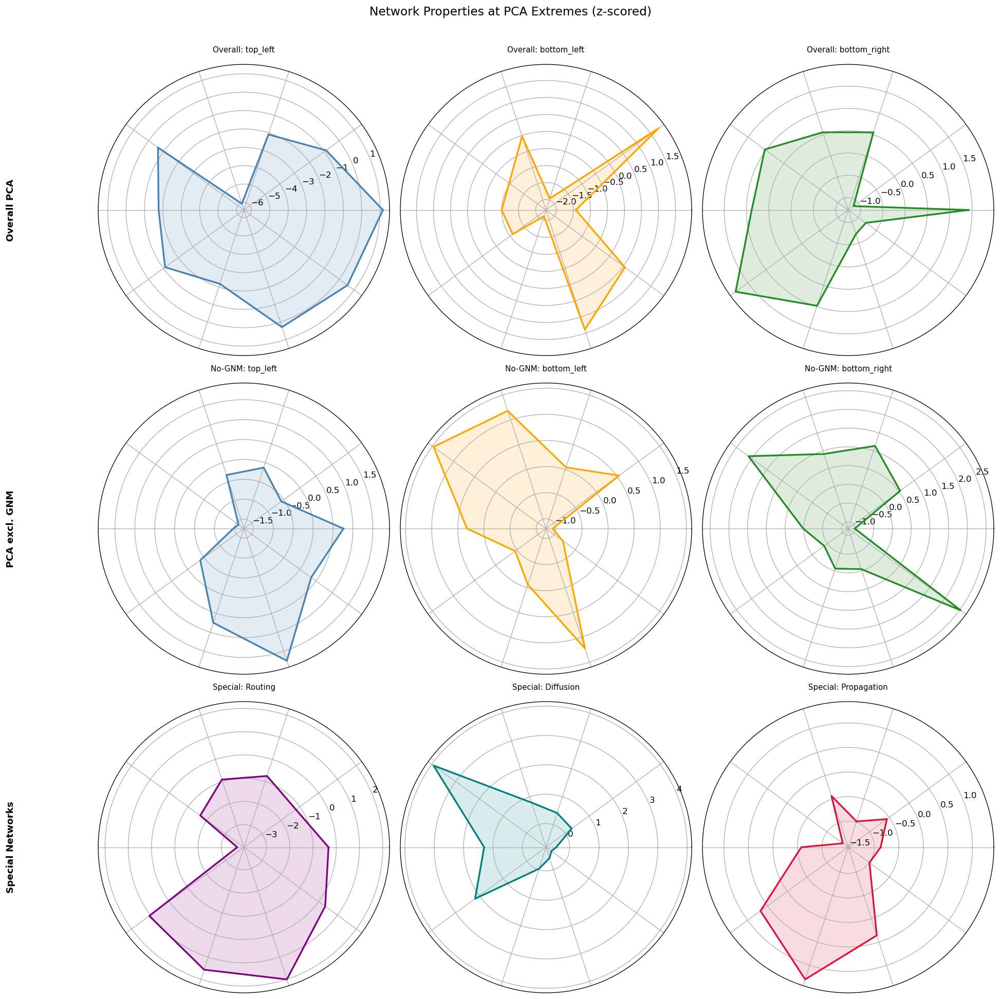

Saved: spider_multipanel.pdf


In [177]:
SPECIAL_DATASETS = {
    "kaysons_generated_networks_routing":     ("Routing",     "purple"),
    "kaysons_generated_networks_diffusion":   ("Diffusion",   "teal"),
    "kaysons_generated_networks_propagation": ("Propagation", "crimson"),
}

# Original row index for single-network datasets
special_indices = {
    ds: int(sel_df_label.index[sel_df_label["dataset"] == ds][0])
    for ds in SPECIAL_DATASETS
}

# ── Build 3 × 3 figure ────────────────────────────────────────────────────────
fig, axs = plt.subplots(3, 3, figsize=(16, 16), subplot_kw=dict(polar=True), dpi=120)

row_configs = [
    # (title prefix, corners_dict or special list, use_corners_colors)
    ("Overall",   list(corners_full.items()),    CORNER_COLORS),
    ("No-GNM",    list(corners_no_gnm.items()),  CORNER_COLORS),
    ("Special",   [(ds, idx) for ds, idx in special_indices.items()], None),
]

for row, (prefix, items, color_map) in enumerate(row_configs):
    for col, (key, orig_idx) in enumerate(items):
        ax = axs[row, col]

        if color_map is not None:
            color = color_map[key]
            label = key
        else:
            label, color = SPECIAL_DATASETS[key]

        vals = list(sel_scaled[orig_idx, rep_idx]) + [sel_scaled[orig_idx, rep_idx[0]]]
        make_spider(ax, vals[:-1], label, color, rep_labels,
                    title=f"{prefix}: {label}")
        # ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.15), fontsize=7))
        ax.set_xticklabels([])  # Hide x-axis labels for cleaner look
        # ax.

# Row annotations
for row, label in enumerate(["Overall PCA", "PCA excl. GNM", "Special Networks"]):
    axs[row, 0].annotate(
        label, xy=(-0.3, 0.5), xycoords="axes fraction",
        fontsize=11, fontweight="bold", ha="center", va="center", rotation=90,
    )

fig.suptitle("Network Properties at PCA Extremes (z-scored)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(output_folder / "spider_multipanel.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: spider_multipanel.pdf")

In [235]:

all_corner_indices = (
    list(corners_full.values()) +
    list(corners_no_gnm.values()) +
    list(special_indices.values())
)
all_vals = np.concatenate([sel_scaled[idx, rep_idx] for idx in all_corner_indices])
# YLIM = (np.floor(all_vals.min()) - 0.5, np.ceil(all_vals.max()) + 0.5)
YLIM = (np.floor(all_vals.min()), np.ceil(all_vals.max()))
# YLIM = [-2, 2] # 4] # 10]
# YLIM = (-3.5, 3.5)  # override to a clean symmetric range if preferred
RING_VALS = [-2, 0, 2] # -6, 2] # 
# RING_VALS = [-1 * YLIM[0], -0.5 * YLIM[0]] + [0] + [0.5 * YLIM[1], 1 * YLIM[1]] # , -2, -1, 1, 2, YLIM[1]] # 2, 2] # [-6, 4] # , 8, 12] # [-8, -6, -4, -2, 2, 4, 6, 8, 10] # [-4, -2, 2, 4]


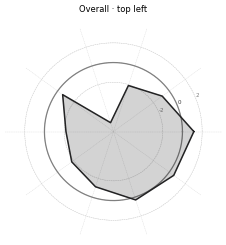

  Saved: spider_overall_top_left.pdf


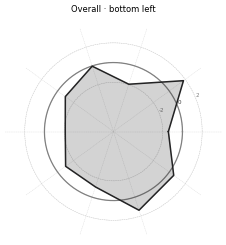

  Saved: spider_overall_bottom_left.pdf


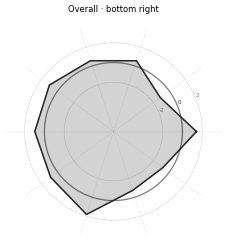

  Saved: spider_overall_bottom_right.pdf


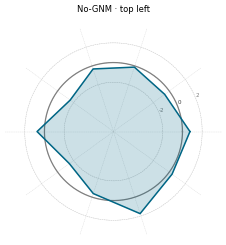

  Saved: spider_no_gnm_top_left.pdf


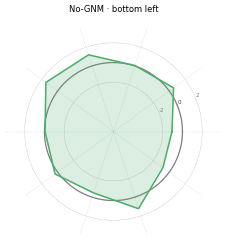

  Saved: spider_no_gnm_bottom_left.pdf


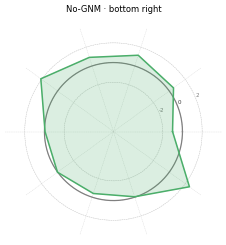

  Saved: spider_no_gnm_bottom_right.pdf


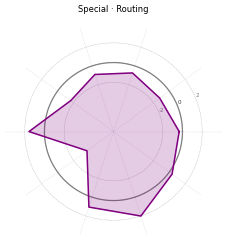

  Saved: spider_special_routing.pdf


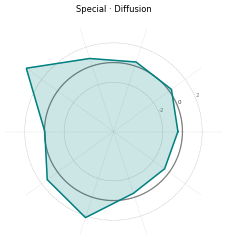

  Saved: spider_special_diffusion.pdf


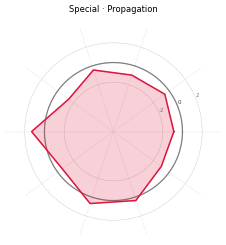

  Saved: spider_special_propagation.pdf
/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/pca_results/spider_special_propagation.pdf


In [238]:
# ── Spider drawing function ────────────────────────────────────────────────────

def make_spider_standalone(values, label, color, feature_labels, title, ylim, filepath):
    n = len(values)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles_closed = angles + angles[:1]
    vals_closed   = list(values) + [values[0]]

    fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True), dpi=50)

    # ── Limits & ticks ──
    ax.set_ylim(*ylim)
    ax.set_yticks(RING_VALS + [0]) # [-2, 0, 2])
    ax.set_yticklabels(RING_VALS + [0], fontsize=8, color="gray")

    # ── Remove outermost border ring ──
    ax.spines["polar"].set_visible(False)

    # ── Custom gridlines: draw manually so we can style zero differently ──
    ax.yaxis.grid(False)   # turn off auto y-gridlines
    ax.xaxis.grid(False)   # turn off auto x-gridlines (spokes we'll redraw)
    theta_ring = np.linspace(0, 2 * np.pi, 300)
    for r_val in RING_VALS: # [-2, 2]:
        ax.plot(theta_ring, np.full(300, r_val),
                color="lightgray", linewidth=0.6, linestyle="--", zorder=0)
    # Zero ring — heavier
    ax.plot(theta_ring, np.zeros(300),
            color="gray", linewidth=1.8, linestyle="-", zorder=1)
    # Other rings: 
    for r_val in RING_VALS:  # YLIM: # [-2, 2]:
        theta_ring = np.linspace(0, 2 * np.pi, 300)
        ax.plot(theta_ring, np.full(300, r_val), color="lightgray", linewidth=0.6, linestyle="--", zorder=0)

    # Spoke lines
    for angle in angles:
        ax.plot([angle, angle], YLIM, # [ylim[0], ylim[1]],
                color="lightgray", linewidth=0.5, linestyle="--", zorder=0)


    # ── Data ──
    ax.plot(angles_closed, vals_closed, color=color, linewidth=2.2, zorder=5)
    ax.fill(angles_closed, vals_closed, color=color, alpha=0.20, zorder=4)

    # ── Feature labels (spokes) — no angle labels by default ──
    ax.set_thetagrids([])          # hide spoke degree labels; add manually below
    ax.set_xticklabels([])

    ax.set_title(title, pad=16) # , fontsize=10, pad=16, fontweight="bold")

    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"  Saved: {filepath.name}")


# ── Build the list of 9 panels ────────────────────────────────────────────────

angles_for_legend = np.linspace(0, 2 * np.pi, len(rep_labels), endpoint=False).tolist()

panels = []

# First 6: Overall and No-GNM corners — color by *dataset* of that point
for corner_name, orig_idx in corners_full.items():
    ds    = sel_df_label["dataset"].iloc[orig_idx]
    color = COLOR_SCHEME[ds]
    vals  = sel_scaled[orig_idx, rep_idx]
    panels.append((f"Overall · {corner_name.replace('_',' ')}", vals, color, f"spider_overall_{corner_name}.pdf"))

for corner_name, orig_idx in corners_no_gnm.items():
    ds    = sel_df_label["dataset"].iloc[orig_idx]
    color = COLOR_SCHEME[ds]
    vals  = sel_scaled[orig_idx, rep_idx]
    panels.append((f"No-GNM · {corner_name.replace('_',' ')}", vals, color, f"spider_no_gnm_{corner_name}.pdf"))

# Last 3: Special single-network datasets
for ds_key, orig_idx in special_indices.items():
    label, color = SPECIAL_DATASETS[ds_key]
    vals = sel_scaled[orig_idx, rep_idx]
    panels.append((f"Special · {label}", vals, color, f"spider_special_{label.lower()}.pdf"))

# ── Save all 9 plots ──────────────────────────────────────────────────────────

for title, vals, color, fname in panels:
    make_spider_standalone(
        values=vals,
        label=title,
        color=color,
        feature_labels=rep_labels,
        title=title,
        ylim=YLIM,
        filepath=output_folder / fname,
    )

print(output_folder / fname) 

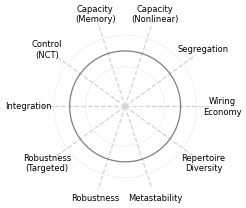

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/pca_results/spider_labels_only.pdf


In [246]:

def make_legend_plot(feature_labels, angles, filepath):
    """Empty radar with only the spoke labels visible."""
    n = len(feature_labels)
    angles_plot = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()

    fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True), dpi=50)
    ax.set_ylim(YLIM[0], YLIM[1]) # -3.5, 3.5)
    ax.set_yticks([])
    ax.spines["polar"].set_visible(False)
    ax.yaxis.grid(False)
    ax.xaxis.grid(False)

    # ax.get_yticklabels(kwargs={"fontsize": 10})  # force generation of ytick labels for correct zorder

    # Draw spoke lines
    for angle in angles_plot:
        ax.plot([angle, angle], YLIM, # [-3.5, 3.5],
                color="lightgray", linewidth=1.8, # 2, # 0.5, 
                linestyle="--", zorder=0)
    # Zero ring
    theta_ring = np.linspace(0, 2 * np.pi, 300)
    ax.plot(theta_ring, np.zeros(300), color="gray", linewidth=1.8, zorder=1)
    # Other rings: 
    for r_val in RING_VALS:  # YLIM: # [-2, 2]:
        theta_ring = np.linspace(0, 2 * np.pi, 300)
        ax.plot(theta_ring, np.full(300, r_val), color="lightgray", linewidth=0.6, linestyle="--", zorder=0)

    # Add spoke labels manually
    for angle, lbl in zip(angles_plot, feature_labels):
        x = np.degrees(angle)
        ax.set_thetagrids(np.degrees(angles_plot), feature_labels, fontsize=12)

    # ax.set_title("Legend / Labels", pad=16) # , fontsize=10, pad=16, fontweight="bold")
    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(filepath)


# ── Save the label-only plot ──────────────────────────────────────────────────

make_legend_plot(rep_labels, angles_for_legend, filepath=output_folder / "spider_labels_only.pdf")


In [275]:
def draw_axis_group_arcs(ax, feature_labels, angles, arc_radius, groups):
    """
    Draw a bold arc just outside the plot connecting paired spokes.
    arc_radius: draw the arc at this r value (slightly beyond local_max).
    """
    theta_dense = np.linspace(0, 2 * np.pi, 1000)

    for label_a, label_b, color in groups:
        if label_a not in feature_labels or label_b not in feature_labels:
            continue
        i_a = feature_labels.index(label_a)
        i_b = feature_labels.index(label_b)

        angle_a = angles[i_a]
        angle_b = angles[i_b]

        # Always sweep the short way between the two spokes
        if angle_b < angle_a:
            angle_a, angle_b = angle_b, angle_a

        # Choose the shorter arc
        if angle_b - angle_a > np.pi:
            arc_angles = np.linspace(angle_b, angle_a + 2 * np.pi, 80)
        else:
            arc_angles = np.linspace(angle_a, angle_b, 80)

        arc_r = np.full_like(arc_angles, arc_radius)

        ax.plot(arc_angles, arc_r,
                color=color, linewidth=3.5, solid_capstyle="round",
                zorder=0, alpha=0.85)

        # Small dots at each endpoint to cap the arc neatly
        ax.scatter([arc_angles[0], arc_angles[-1]],
                   [arc_radius, arc_radius],
                   color=color, s=18, zorder=7, alpha=0.85)


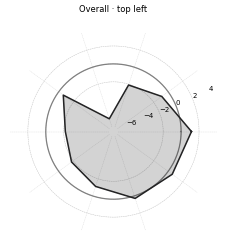

  Saved: spider_overall_top_left.pdf


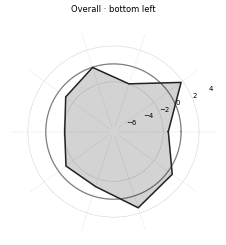

  Saved: spider_overall_bottom_left.pdf


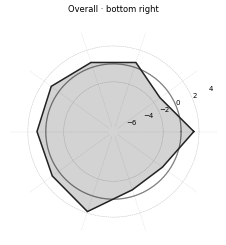

  Saved: spider_overall_bottom_right.pdf


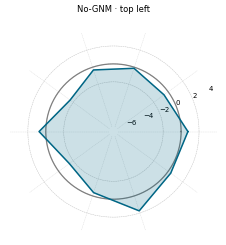

  Saved: spider_no_gnm_top_left.pdf


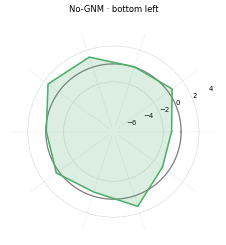

  Saved: spider_no_gnm_bottom_left.pdf


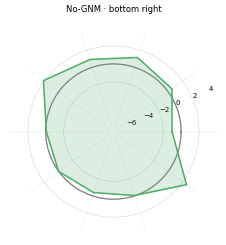

  Saved: spider_no_gnm_bottom_right.pdf


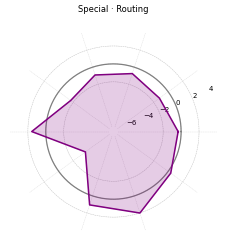

  Saved: spider_special_routing.pdf


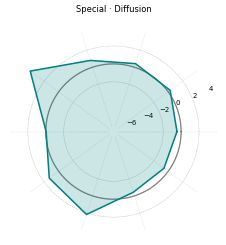

  Saved: spider_special_diffusion.pdf


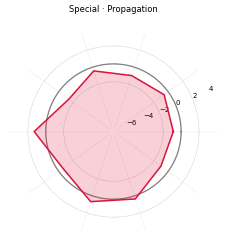

  Saved: spider_special_propagation.pdf


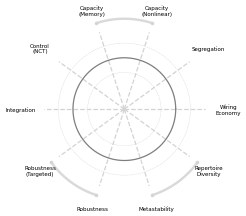

  Saved: spider_labels_only.pdf

Done — 10 files saved.
Files are in: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/pca_results


In [276]:
# ── Global y-range (shared across all plots) ──────────────────────────────────

all_corner_indices = (
    list(corners_full.values()) +
    list(corners_no_gnm.values()) +
    list(special_indices.values())
)
all_vals = np.concatenate([sel_scaled[idx, rep_idx] for idx in all_corner_indices])
# YLIM = (np.floor(all_vals.min()) - 0.5, np.ceil(all_vals.max()) + 0.5)
YLIM = (np.floor(all_vals.min()), np.ceil(all_vals.max()))
# YLIM = [-2, 2] # 4] # 10]
# YLIM = (-3.5, 3.5)  # override to a clean symmetric range if preferred
RING_VALS = [-2, 0, 2] # -6, 2] # 
# RING_VALS = [-1 * YLIM[0], -0.5 * YLIM[0]] + [0] + [0.5 * YLIM[1], 1 * YLIM[1]] # , -2, -1, 1, 2, YLIM[1]] # 2, 2] # [-6, 4] # , 8, 12] # [-8, -6, -4, -2, 2, 4, 6, 8, 10] # [-4, -2, 2, 4]

AXIS_GROUPS = [
    ("Capacity\n(Nonlinear)", "Capacity\n(Memory)",     "lightgray"), # "#E07B39"),  # orange
    ("Robustness\n(Targeted)", "Robustness",              "lightgray"),  # "#5B8DB8"),  # blue
    ("Metastability",          "Repertoire\nDiversity",   "lightgray"),  # "#6AAB6A"),  # green
]

# ── Spider drawing function ────────────────────────────────────────────────────

def make_spider_standalone(values, label, color, feature_labels, title, ylim, filepath):
    n = len(values)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles_closed = angles + angles[:1]
    vals_closed   = list(values) + [values[0]]

    fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True), dpi=50)

    # ── Limits & ticks ──
    # ax.set_ylim(*ylim)
    # ax.set_yticks(RING_VALS + [0]) # [-2, 0, 2])
    # ax.set_yticklabels(RING_VALS + [0], fontsize=8, color="gray")
    # ax.set_yticklabels(fontsize=8, color="gray")

    # ── Remove outermost border ring ──
    ax.spines["polar"].set_visible(False)

    # ── Custom gridlines: draw manually so we can style zero differently ──
    ax.yaxis.grid(False)   # turn off auto y-gridlines
    ax.xaxis.grid(False)   # turn off auto x-gridlines (spokes we'll redraw)
    theta_ring = np.linspace(0, 2 * np.pi, 300)
    for r_val in RING_VALS: # [-2, 2]:
        ax.plot(theta_ring, np.full(300, r_val),
                color="lightgray", linewidth=0.6, linestyle="--", zorder=0)
    # Zero ring — heavier
    ax.plot(theta_ring, np.zeros(300),
            color="gray", linewidth=1.8, linestyle="-", zorder=1)
    # Other rings: 
    for r_val in RING_VALS:  # YLIM: # [-2, 2]:
        theta_ring = np.linspace(0, 2 * np.pi, 300)
        ax.plot(theta_ring, np.full(300, r_val), color="lightgray", linewidth=0.6, linestyle="--", zorder=0)

    # Spoke lines
    for angle in angles:
        ax.plot([angle, angle], YLIM, # [ylim[0], ylim[1]],
                color="lightgray", linewidth=0.5, linestyle="--", zorder=0)


    # ── Data ──
    ax.plot(angles_closed, vals_closed, color=color, linewidth=2.2, zorder=5)
    ax.fill(angles_closed, vals_closed, color=color, alpha=0.20, zorder=4)

    # ── Feature labels (spokes) — no angle labels by default ──
    ax.set_thetagrids([])          # hide spoke degree labels; add manually below
    ax.set_xticklabels([])

    ax.set_title(title, pad=16) # , fontsize=10, pad=16, fontweight="bold")

    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"  Saved: {filepath.name}")


def make_legend_plot(feature_labels, angles, filepath):
    """Empty radar with only the spoke labels visible."""
    n = len(feature_labels)
    angles_plot = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()

    fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True), dpi=50)
    ax.set_ylim(YLIM[0], YLIM[1]) # -3.5, 3.5)
    ax.set_yticks([])
    ax.spines["polar"].set_visible(False)
    ax.yaxis.grid(False)
    ax.xaxis.grid(False)

    # Draw spoke lines
    for angle in angles_plot:
        ax.plot([angle, angle], YLIM, # [-3.5, 3.5],
                color="lightgray", linewidth=1.8, # 2, # 0.5, 
                linestyle="--", zorder=0)
        
    # ── Group arcs just outside the outermost ring ──
    local_min, local_max = YLIM[0], YLIM[1]
    arc_r = local_max + (local_max - local_min) * 0.12
    draw_axis_group_arcs(ax, list(feature_labels), angles, arc_r, AXIS_GROUPS)
    # Expand ylim slightly so the arc isn't clipped
    ax.set_ylim(local_min, arc_r + (local_max - local_min) * 0.05)

    # Zero ring
    theta_ring = np.linspace(0, 2 * np.pi, 300)
    ax.plot(theta_ring, np.zeros(300), color="gray", linewidth=1.8, zorder=1)
    # Other rings: 
    for r_val in RING_VALS:  # YLIM: # [-2, 2]:
        theta_ring = np.linspace(0, 2 * np.pi, 300)
        ax.plot(theta_ring, np.full(300, r_val), color="lightgray", linewidth=0.6, linestyle="--", zorder=0)
        

    # Add spoke labels manually
    for angle, lbl in zip(angles_plot, feature_labels):
        x = np.degrees(angle)
        ax.set_thetagrids(np.degrees(angles_plot), feature_labels, fontsize=8)
        

    # ax.set_title("Legend / Labels", pad=16) # , fontsize=10, pad=16, fontweight="bold")
    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"  Saved: {filepath.name}")


# ── Build the list of 9 panels ────────────────────────────────────────────────

angles_for_legend = np.linspace(0, 2 * np.pi, len(rep_labels), endpoint=False).tolist()

panels = []

# First 6: Overall and No-GNM corners — color by *dataset* of that point
for corner_name, orig_idx in corners_full.items():
    ds    = sel_df_label["dataset"].iloc[orig_idx]
    color = COLOR_SCHEME[ds]
    vals  = sel_scaled[orig_idx, rep_idx]
    panels.append((f"Overall · {corner_name.replace('_',' ')}", vals, color, f"spider_overall_{corner_name}.pdf"))

for corner_name, orig_idx in corners_no_gnm.items():
    ds    = sel_df_label["dataset"].iloc[orig_idx]
    color = COLOR_SCHEME[ds]
    vals  = sel_scaled[orig_idx, rep_idx]
    panels.append((f"No-GNM · {corner_name.replace('_',' ')}", vals, color, f"spider_no_gnm_{corner_name}.pdf"))

# Last 3: Special single-network datasets
for ds_key, orig_idx in special_indices.items():
    label, color = SPECIAL_DATASETS[ds_key]
    vals = sel_scaled[orig_idx, rep_idx]
    panels.append((f"Special · {label}", vals, color, f"spider_special_{label.lower()}.pdf"))

# ── Save all 9 plots ──────────────────────────────────────────────────────────

for title, vals, color, fname in panels:
    make_spider_standalone(
        values=vals,
        label=title,
        color=color,
        feature_labels=rep_labels,
        title=title,
        ylim=YLIM,
        filepath=output_folder / fname,
    )

# ── Save the label-only plot ──────────────────────────────────────────────────

make_legend_plot(rep_labels, angles_for_legend, filepath=output_folder / "spider_labels_only.pdf")

print("\nDone — 10 files saved.")
print(f"Files are in: {output_folder.resolve()}")

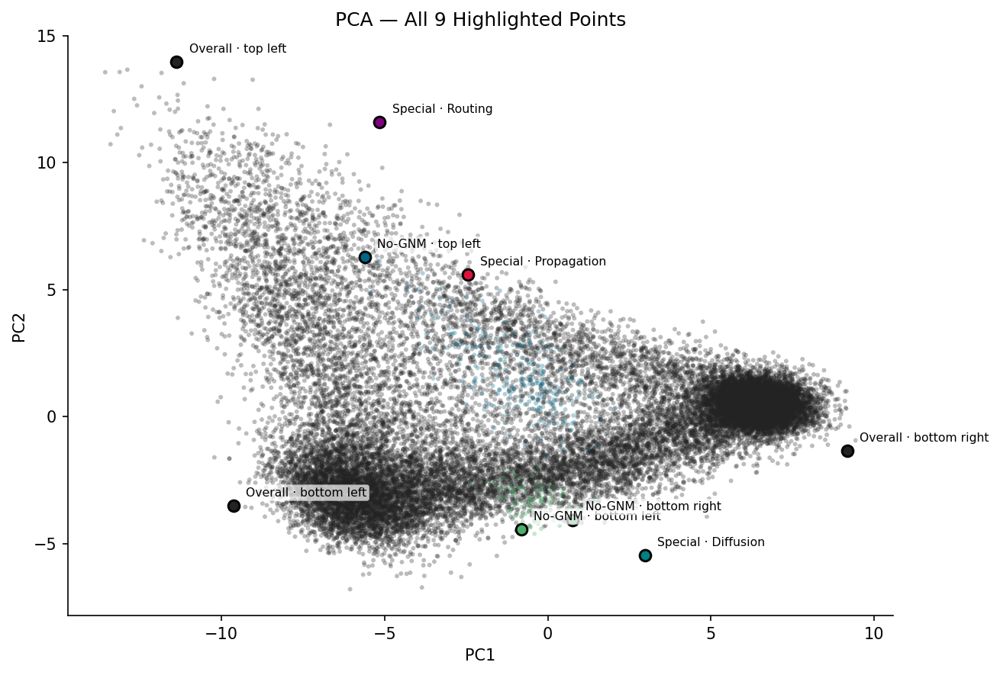

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/pca_results/pca_highlighted_9points.pdf


In [179]:
# ── Build color + label lookup for all 9 highlighted points ──────────────────
highlighted = {}

# First 6: corners_full and corners_no_gnm — same color logic as spider plots
for corner_name, orig_idx in corners_full.items():
    ds    = sel_df_label["dataset"].iloc[orig_idx]
    color = COLOR_SCHEME[ds]
    label = f"Overall · {corner_name.replace('_', ' ')}"
    highlighted[label] = {"idx": orig_idx, "color": color, # "marker": "o", 
                          "source": "full"}

for corner_name, orig_idx in corners_no_gnm.items():
    ds    = sel_df_label["dataset"].iloc[orig_idx]
    color = COLOR_SCHEME[ds]
    label = f"No-GNM · {corner_name.replace('_', ' ')}"
    highlighted[label] = {"idx": orig_idx, "color": color, # "marker": "s", 
                          "source": "no_gnm"}

# Last 3: special datasets
for ds_key, orig_idx in special_indices.items():
    sp_label, color = SPECIAL_DATASETS[ds_key]
    label = f"Special · {sp_label}"
    highlighted[label] = {"idx": orig_idx, "color": color, # "marker": "^", 
                          "source": "special"}

# ── PCA scatter — background points ──────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

for ds in sel_df_label["dataset"].unique():
    mask = (sel_df_label["dataset"] == ds).values
    ax.scatter(
        sel_pca_result[mask, 0], sel_pca_result[mask, 1],
        c=COLOR_SCHEME[ds], label=LABEL_MAP.get(ds, ds),
        alpha=0.3, s=8, edgecolors="none", zorder=1,
    )

# ── Highlighted points ────────────────────────────────────────────────────────

marker_legend = {"full": ("o", "Overall corner"), "no_gnm": ("s", "No-GNM corner"), "special": ("^", "Special network")}

for label, info in highlighted.items():
    idx    = info["idx"]
    color  = info["color"]
    # marker = info["marker"]
    ax.scatter(
        sel_pca_result[idx, 0], sel_pca_result[idx, 1],
        color=color, # marker=marker,
        s=50, # 220, 
        zorder=6,
        edgecolors="black", linewidths=1.4,
    )
    
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlabel("PC1") # , fontsize=10)
ax.set_ylabel("PC2") # , fontsize=10)
ax.set_title("PCA — All 9 Highlighted Points") # , fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig(output_folder / "pca_highlighted_9points.pdf", dpi=150, bbox_inches="tight")



for label, info in highlighted.items():
    idx    = info["idx"]
    color  = info["color"]
    ax.annotate(
        label,
        (sel_pca_result[idx, 0], sel_pca_result[idx, 1]),
        textcoords="offset points", xytext=(8, 6),
        fontsize=7.5, zorder=7,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7),
    )


plt.show()
print(output_folder / "pca_highlighted_9points.pdf")

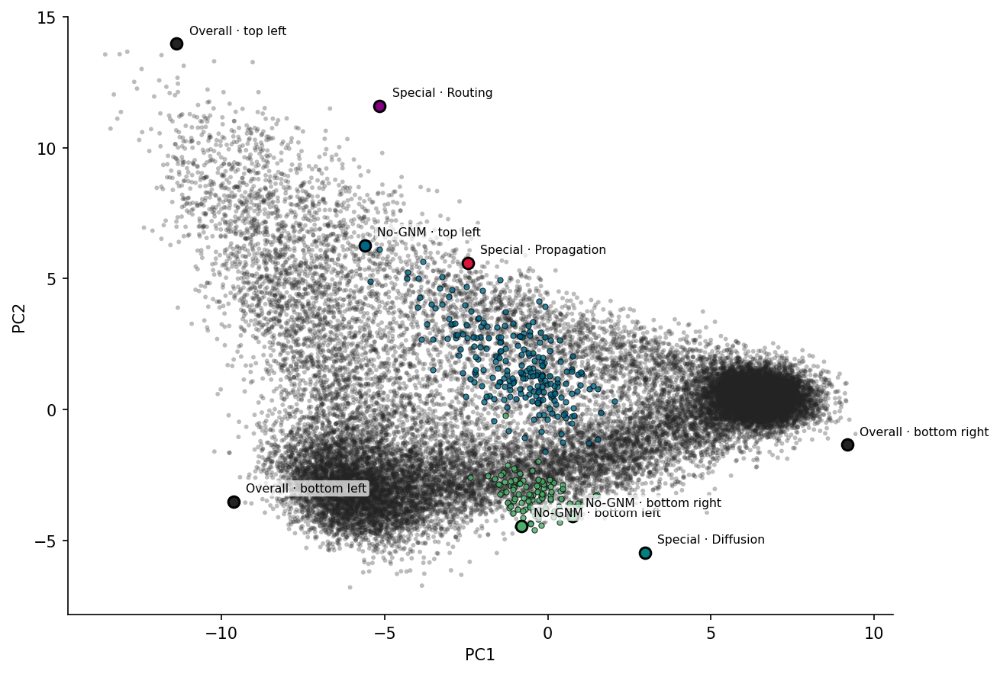

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/pca_results/pca_highlighted_9points.pdf


In [180]:
# ── Build color + label lookup for all 9 highlighted points ──────────────────
highlighted = {}

# First 6: corners_full and corners_no_gnm — same color logic as spider plots
for corner_name, orig_idx in corners_full.items():
    ds    = sel_df_label["dataset"].iloc[orig_idx]
    color = COLOR_SCHEME[ds]
    label = f"Overall · {corner_name.replace('_', ' ')}"
    highlighted[label] = {"idx": orig_idx, "color": color, # "marker": "o", 
                          "source": "full"}

for corner_name, orig_idx in corners_no_gnm.items():
    ds    = sel_df_label["dataset"].iloc[orig_idx]
    color = COLOR_SCHEME[ds]
    label = f"No-GNM · {corner_name.replace('_', ' ')}"
    highlighted[label] = {"idx": orig_idx, "color": color, # "marker": "s", 
                          "source": "no_gnm"}

# Last 3: special datasets
for ds_key, orig_idx in special_indices.items():
    sp_label, color = SPECIAL_DATASETS[ds_key]
    label = f"Special · {sp_label}"
    highlighted[label] = {"idx": orig_idx, "color": color, # "marker": "^", 
                          "source": "special"}

# ── PCA scatter — background points ──────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

for ds in sel_df_label["dataset"].unique():
    mask = (sel_df_label["dataset"] == ds).values
    ax.scatter(
        sel_pca_result[mask, 0], sel_pca_result[mask, 1],
        c=COLOR_SCHEME[ds], 
        label=LABEL_MAP.get(ds, ds),
        alpha=0.3 if ds == GNM_DATASET else 0.8, 
        s=8 if ds == GNM_DATASET else 12, 
        edgecolors="none" if ds == GNM_DATASET else "black", 
        linewidths=0 if ds == GNM_DATASET else 0.5,
        zorder=1,
    )

# ── Highlighted points ────────────────────────────────────────────────────────

marker_legend = {"full": ("o", "Overall corner"), 
                 "no_gnm": ("s", "No-GNM corner"), 
                 "special": ("^", "Special network")}

for label, info in highlighted.items():
    idx    = info["idx"]
    color  = info["color"]
    # marker = info["marker"]
    ax.scatter(
        sel_pca_result[idx, 0], sel_pca_result[idx, 1],
        color=color, # marker=marker,
        s=50, # 220, 
        zorder=6,
        edgecolors="black", 
        linewidths=1.4,
    )
    
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlabel("PC1") # , fontsize=10)
ax.set_ylabel("PC2") # , fontsize=10)
# ax.set_title("PCA — All 9 Highlighted Points") # , fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig(output_folder / "pca_highlighted_9points.pdf", dpi=150, bbox_inches="tight")



for label, info in highlighted.items():
    idx    = info["idx"]
    color  = info["color"]
    ax.annotate(
        label,
        (sel_pca_result[idx, 0], sel_pca_result[idx, 1]),
        textcoords="offset points", xytext=(8, 6),
        fontsize=7.5, zorder=7,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7),
    )


plt.show()
print(output_folder / "pca_highlighted_9points.pdf")

In [ ]:



# Turn eta and gamma into two different colorchannels for the t-SNE and UMAP plots
# For example, use eta for hue and gamma for saturation (or size)
from matplotlib.colors import Normalize

# Normalize the eta and gamma values
eta_norm = Normalize()(huge_df["eta"])
gamma_norm = Normalize()(huge_df["gamma"])

# Create a colormap for eta (hue) and gamma (saturation)
# cmap_eta = plt.cm.viridis  # You can choose any colormap you like
# cmap_gamma = plt.cm.gray  # Grayscale for saturation
# # Map normalized eta and gamma to colors
# colors_eta = cmap_eta(eta_norm)
# colors_gamma = cmap_gamma(gamma_norm)
# combined_colors = (colors_eta[:, :3] + colors_gamma[:, :3]) / 2

# cmap_eta = plt.cm.Reds # 
cmap_eta = plt.cm.YlOrRd
cmap_gamma = plt.cm.Blues # Greys # Reds #] Blues
# Map normalized eta and gamma to colors
colors_eta = cmap_eta(eta_norm)
colors_gamma = cmap_gamma(gamma_norm)
# Combine the two color channels (for simplicity, we'll just average them here)
# combined_colors = (colors_eta[:, :3] * colors_gamma[:, :3]) 
# combined_colors = combined_colors / np.max(combined_colors, axis=0)
combined_colors = (colors_eta[:, :3] + colors_gamma[:, :3]) / 2


NameError: name 'huge_df' is not defined

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/pca_results/eta_gamma_color_mapping.pdf


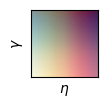

In [182]:
plt.figure(figsize=viz.cm_to_inch((3,3)))
plt.scatter(huge_df["eta"], huge_df["gamma"], c=combined_colors, s=2, edgecolors="none")
plt.xlabel(r"$\eta$")
plt.ylabel(r"$\gamma$")
plt.xticks([])
plt.yticks([])
plt.xlim(-8,3)
plt.ylim(-0.1,1)
plt.tight_layout()
plt.savefig(output_folder / "eta_gamma_color_mapping.pdf", dpi=150, bbox_inches="tight")
print(output_folder / "eta_gamma_color_mapping.pdf")

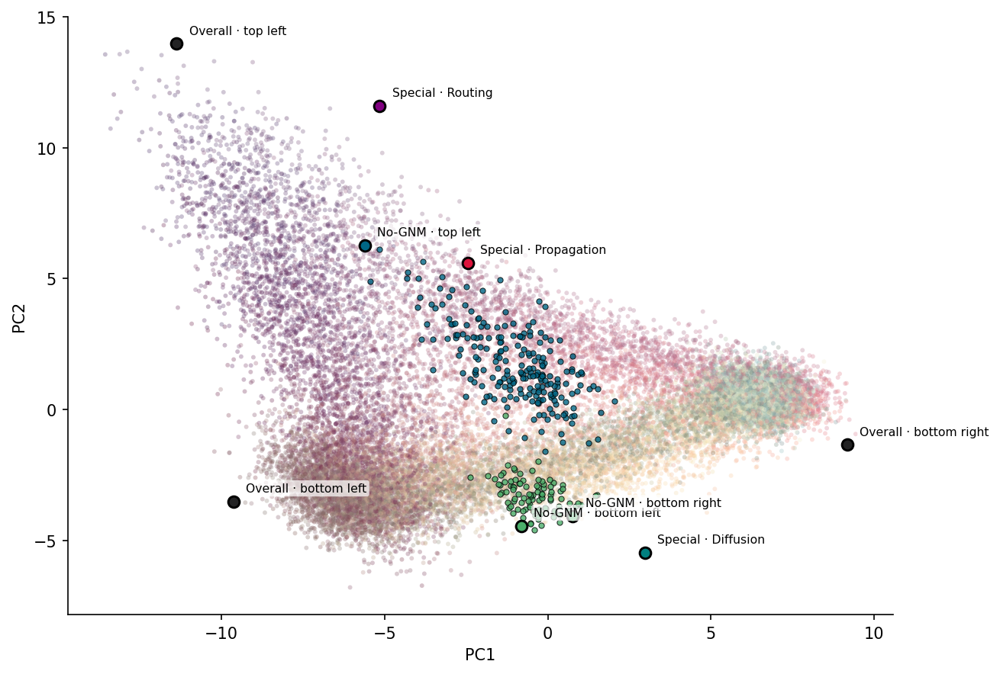

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/pca_results/pca_highlighted_9points.pdf


In [183]:
# ── Build color + label lookup for all 9 highlighted points ──────────────────
highlighted = {}

# First 6: corners_full and corners_no_gnm — same color logic as spider plots
for corner_name, orig_idx in corners_full.items():
    ds    = sel_df_label["dataset"].iloc[orig_idx]
    color = COLOR_SCHEME[ds] # if ds != GNM_DATASET else combined_colors[orig_idx]
    label = f"Overall · {corner_name.replace('_', ' ')}"
    highlighted[label] = {"idx": orig_idx, "color": color, # "marker": "o", 
                          "source": "full"}

for corner_name, orig_idx in corners_no_gnm.items():
    ds    = sel_df_label["dataset"].iloc[orig_idx]
    color = COLOR_SCHEME[ds] # if ds != GNM_DATASET else combined_colors[orig_idx]
    label = f"No-GNM · {corner_name.replace('_', ' ')}"
    highlighted[label] = {"idx": orig_idx, "color": color, # "marker": "s", 
                          "source": "no_gnm"}

# Last 3: special datasets
for ds_key, orig_idx in special_indices.items():
    sp_label, color = SPECIAL_DATASETS[ds_key]
    label = f"Special · {sp_label}"
    highlighted[label] = {"idx": orig_idx, "color": color, # "marker": "^", 
                          "source": "special"}

# ── PCA scatter — background points ──────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

for ds in sel_df_label["dataset"].unique():
    mask = (sel_df_label["dataset"] == ds).values
    ax.scatter(
        sel_pca_result[mask, 0], sel_pca_result[mask, 1],
        c=COLOR_SCHEME[ds] if ds != GNM_DATASET else combined_colors[mask],
        label=LABEL_MAP.get(ds, ds),
        alpha=0.3 if ds == GNM_DATASET else 0.8, 
        s=8 if ds == GNM_DATASET else 12, 
        edgecolors="none" if ds == GNM_DATASET else "black", 
        linewidths=0 if ds == GNM_DATASET else 0.5,
        zorder=1,
    )

# ── Highlighted points ────────────────────────────────────────────────────────

marker_legend = {"full": ("o", "Overall corner"), 
                 "no_gnm": ("s", "No-GNM corner"), 
                 "special": ("^", "Special network")}

for label, info in highlighted.items():
    idx    = info["idx"]
    color  = info["color"]
    # marker = info["marker"]
    ax.scatter(
        sel_pca_result[idx, 0], sel_pca_result[idx, 1],
        color=color, # marker=marker,
        s=50, # 220, 
        zorder=6,
        edgecolors="black", 
        linewidths=1.4,
    )
    
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlabel("PC1") # , fontsize=10)
ax.set_ylabel("PC2") # , fontsize=10)
# ax.set_title("PCA — All 9 Highlighted Points") # , fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig(output_folder / "pca_highlighted_9points.pdf", dpi=150, bbox_inches="tight")



for label, info in highlighted.items():
    idx    = info["idx"]
    color  = info["color"]
    ax.annotate(
        label,
        (sel_pca_result[idx, 0], sel_pca_result[idx, 1]),
        textcoords="offset points", xytext=(8, 6),
        fontsize=7.5, zorder=7,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7),
    )


plt.show()
print(output_folder / "pca_highlighted_9points.pdf")

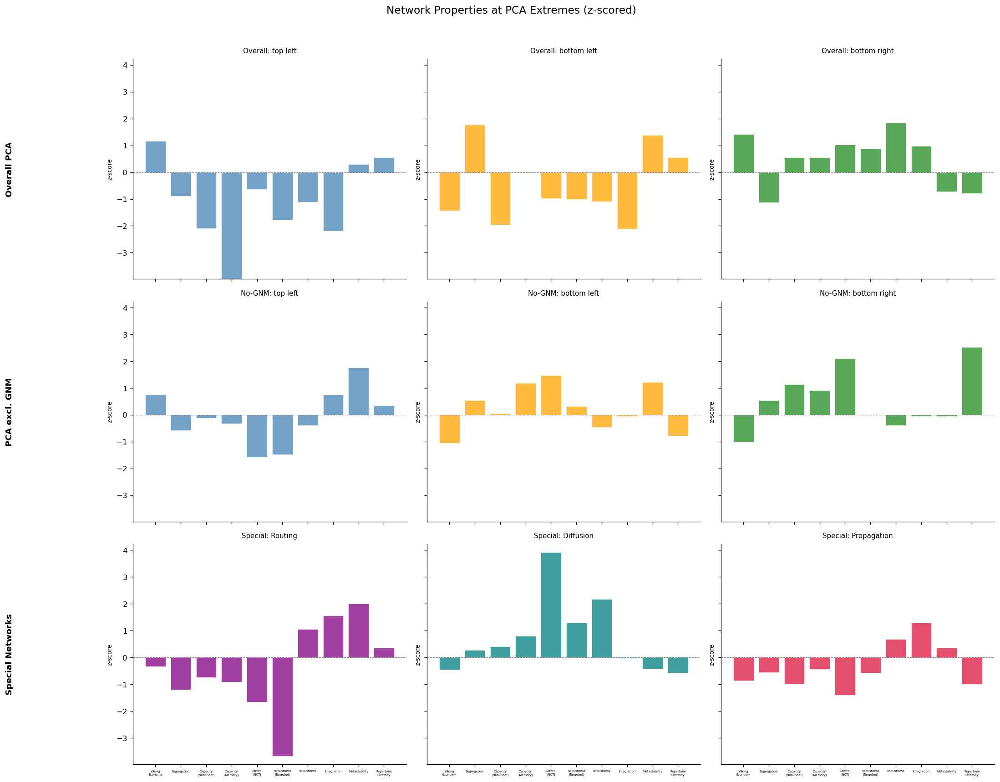

Saved: bar_multipanel.pdf


In [184]:
# ── Helper: draw one bar chart onto a regular axis ────────────────────────────

def make_bar(ax, values, label, color, feature_labels, title=None):
    x = np.arange(len(values))
    bars = ax.bar(x, values, color=color, alpha=0.75, edgecolor="white", linewidth=0.5)
    ax.axhline(0, color="black", linewidth=0.7, linestyle="--", alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(feature_labels, # otation=90, # 45,
                    #    ha="right", 
                       fontsize=4)
    ax.set_ylabel("z-score", fontsize=8)
    if title:
        ax.set_title(title, fontsize=9, pad=8)
    ax.spines[["top", "right"]].set_visible(False)

# ── Build 3 × 3 figure ────────────────────────────────────────────────────────

fig, axs = plt.subplots(3, 3, figsize=(18, 14), dpi=120, sharex=True, sharey=True)

# Compute a shared y-axis range across all panels for comparability
all_vals = [sel_scaled[idx, rep_idx] for idx in list({**corners_full, **corners_no_gnm}.values())]
all_vals += [sel_scaled[idx, rep_idx] for idx in special_indices.values()]
global_min = min(v.min() for v in all_vals) - 0.3
global_max = max(v.max() for v in all_vals) + 0.3

row_configs = [
    ("Overall",  list(corners_full.items()),                                  CORNER_COLORS),
    ("No-GNM",   list(corners_no_gnm.items()),                                CORNER_COLORS),
    ("Special",  [(ds, idx) for ds, idx in special_indices.items()],          None),
]

for row, (prefix, items, color_map) in enumerate(row_configs):
    for col, (key, orig_idx) in enumerate(items):
        ax = axs[row, col]

        if color_map is not None:
            color = color_map[key]
            label = key.replace("_", " ")
        else:
            label, color = SPECIAL_DATASETS[key]

        vals = sel_scaled[orig_idx, rep_idx]
        make_bar(ax, vals, label, color, rep_labels, title=f"{prefix}: {label}")
        ax.set_ylim(global_min, global_max)

# Row annotations
for row, row_label in enumerate(["Overall PCA", "PCA excl. GNM", "Special Networks"]):
    axs[row, 0].annotate(
        row_label, xy=(-0.45, 0.5), xycoords="axes fraction",
        fontsize=11, fontweight="bold", ha="center", va="center", rotation=90,
    )

fig.suptitle("Network Properties at PCA Extremes (z-scored)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(output_folder / "bar_multipanel.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: bar_multipanel.pdf")

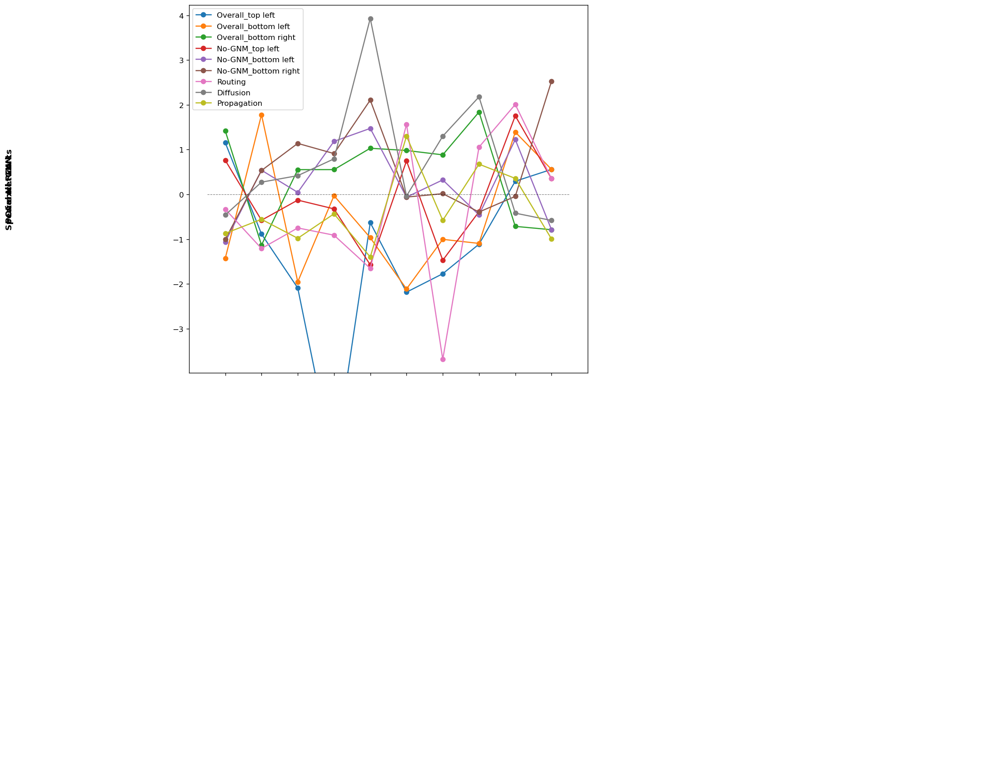

Saved: bar_multipanel.pdf


In [260]:
# ── Helper: draw one bar chart onto a regular axis ────────────────────────────

def make_bar(ax, values, label, color, feature_labels, title=None):
    x = np.arange(len(values))
    bars = ax.bar(x, values, color=color, alpha=0.75, edgecolor="white", linewidth=0.5)
    ax.axhline(0, color="black", linewidth=0.7, linestyle="--", alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(feature_labels, rotation=45, ha="right", fontsize=7)
    ax.set_ylabel("z-score", fontsize=8)
    if title:
        ax.set_title(title, fontsize=9, pad=8)
    ax.spines[["top", "right"]].set_visible(False)

# ── Build 3 × 3 figure ────────────────────────────────────────────────────────

fig, axs = plt.subplots(2,2, figsize=(18, 14), dpi=120, sharex=True, sharey=True)

# Compute a shared y-axis range across all panels for comparability
all_vals = [sel_scaled[idx, rep_idx] for idx in list({**corners_full, **corners_no_gnm}.values())]
all_vals += [sel_scaled[idx, rep_idx] for idx in special_indices.values()]
global_min = min(v.min() for v in all_vals) - 0.3
global_max = max(v.max() for v in all_vals) + 0.3

row_configs = [
    ("Overall",  list(corners_full.items()),                                  CORNER_COLORS),
    ("No-GNM",   list(corners_no_gnm.items()),                                CORNER_COLORS),
    ("Special",  [(ds, idx) for ds, idx in special_indices.items()],          None),
]

for row, (prefix, items, color_map) in enumerate(row_configs):
    for col, (key, orig_idx) in enumerate(items):
        # ax = axs[row, col]
        ax = axs[0, 0]

        if color_map is not None:
            color = color_map[key]
            label = prefix + "_" + key.replace("_", " ")
        else:
            label, color = SPECIAL_DATASETS[key]

        vals = sel_scaled[orig_idx, rep_idx]
        # make_bar(ax, vals, label, color, rep_labels, title=f"{prefix}: {label}")
        ax.plot(vals, label=label, # color=color, 
                marker="o")
        ax.set_ylim(global_min, global_max)
        
                
        # axs[0, 0].set_xticks(range(len(rep_labels)))
        ax.set_xticks(range(len(vals)))
        ax.set_xticklabels(rep_labels, rotation=45, ha="right", fontsize=7)

# Row annotations
for row, row_label in enumerate(["Overall PCA", "PCA excl. GNM", "Special Networks"]):
    # axs[row, 0].annotate(
    axs[0, 0].annotate(
        row_label, xy=(-0.45, 0.5), xycoords="axes fraction",
        fontsize=11, fontweight="bold", ha="center", va="center", rotation=90,
    )
    
axs[0,0].legend() 
axs[0,0].hlines(0, xmin=-0.5, xmax=len(rep_labels)-0.5, color="black", linewidth=0.7, linestyle="--", alpha=0.5)

# axs[0, 0].set_xticks(range(len(rep_labels)))
# axs[0, 0].set_xticks(range(len(rep_labels)))
# axs[0, 0].set_xticklabels(rep_labels, rotation=45, ha="right", fontsize=7)

# remove all unnecessary axes
for row in range(2):
    for col in range(2):
        if (row, col) != (0, 0):
            axs[row, col].axis("off")

# plt.legend()
# fig.suptitle("Network Properties at PCA Extremes (z-scored)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(output_folder / "bar_multipanel.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: bar_multipanel.pdf")

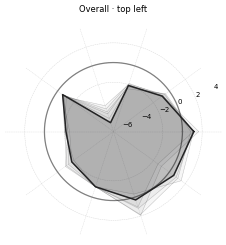

  Saved: spider_overall_top_left.pdf


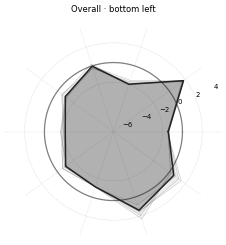

  Saved: spider_overall_bottom_left.pdf


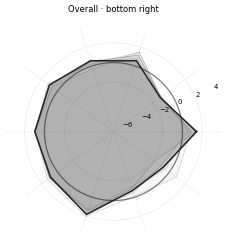

  Saved: spider_overall_bottom_right.pdf


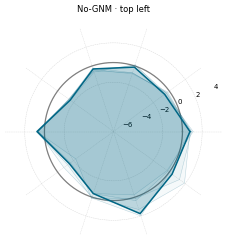

  Saved: spider_no_gnm_top_left.pdf


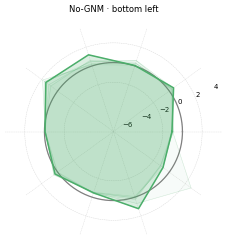

  Saved: spider_no_gnm_bottom_left.pdf


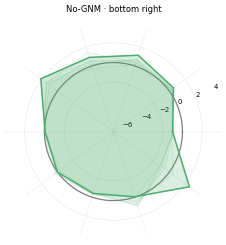

  Saved: spider_no_gnm_bottom_right.pdf


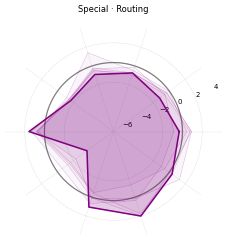

  Saved: spider_special_routing.pdf


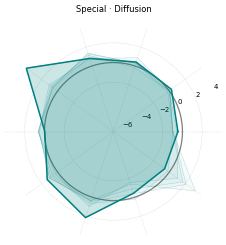

  Saved: spider_special_diffusion.pdf


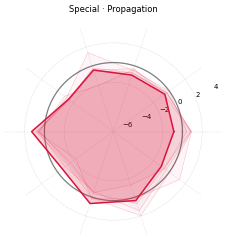

  Saved: spider_special_propagation.pdf


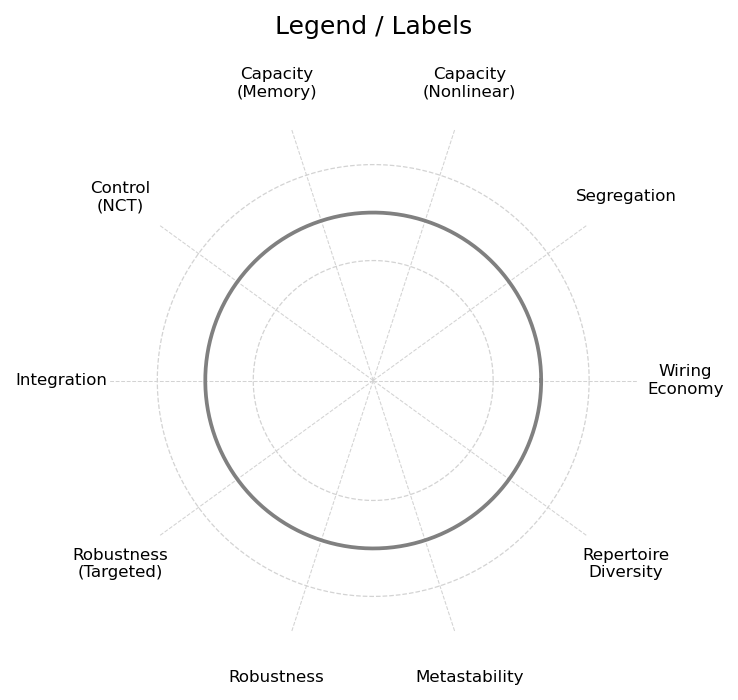

  Saved: spider_labels_only.pdf

Done — 10 files saved.


In [261]:
from sklearn.metrics import pairwise_distances

# ── Compute 5 nearest neighbours for each panel point ────────────────────────
# Use the full PCA embedding (all 10 components) for distance

def get_neighbours(orig_idx, pca_result, n=5, exclude_gnm=False, df_label=None, gnm_name=None):
    """Return indices of the n closest rows in pca_result to orig_idx."""
    dists = pairwise_distances(pca_result[orig_idx:orig_idx+1], pca_result)[0]
    dists[orig_idx] = np.inf  # exclude self
    if exclude_gnm and df_label is not None:
        gnm_mask = (df_label["dataset"] == gnm_name).values
        dists[gnm_mask] = np.inf
    return np.argsort(dists)[:n].tolist()


# ── Modified spider drawing function with neighbours ─────────────────────────

def make_spider_standalone(values, label, color, feature_labels, title, ylim,
                           filepath, neighbour_vals_list=None):
    n = len(values)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles_closed = angles + angles[:1]
    vals_closed   = list(values) + [values[0]]

    fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True), dpi=50)

    ax.set_ylim(*ylim)
    ax.spines["polar"].set_visible(False)
    ax.yaxis.grid(False)
    ax.xaxis.grid(False)

    theta_ring = np.linspace(0, 2 * np.pi, 300)

    # ── Gridlines ──
    for r_val in RING_VALS:
        ax.plot(theta_ring, np.full(300, r_val),
                color="lightgray", linewidth=0.6, linestyle="--", zorder=0)
    ax.plot(theta_ring, np.zeros(300),
            color="gray", linewidth=1.8, linestyle="-", zorder=1)
    for angle in angles:
        ax.plot([angle, angle], ylim,
                color="lightgray", linewidth=0.5, linestyle="--", zorder=0)

    # ── Neighbour lines (faded, thin, same color) ──
    if neighbour_vals_list is not None:
        for nb_vals in neighbour_vals_list:
            nb_closed = list(nb_vals) + [nb_vals[0]]
            ax.plot(angles_closed, nb_closed,
                    color=color, linewidth=0.6, alpha=0.25, zorder=3)
            ax.fill(angles_closed, nb_closed,
                    color=color, alpha=0.04, zorder=2)

    # ── Main data (on top) ──
    ax.plot(angles_closed, vals_closed, color=color, linewidth=2.2, zorder=5)
    ax.fill(angles_closed, vals_closed, color=color, alpha=0.20, zorder=4)

    ax.set_thetagrids([])
    ax.set_xticklabels([])
    ax.set_title(title, pad=16)

    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"  Saved: {filepath.name}")


# ── Rebuild panels list with neighbour data ───────────────────────────────────

panels = []

# First 6: Overall and No-GNM corners
for corner_name, orig_idx in corners_full.items():
    ds    = sel_df_label["dataset"].iloc[orig_idx]
    color = COLOR_SCHEME[ds]
    nb_idx = get_neighbours(orig_idx, sel_pca_result, n=5)
    nb_vals = [sel_scaled[i, rep_idx] for i in nb_idx]
    panels.append((
        f"Overall · {corner_name.replace('_', ' ')}",
        sel_scaled[orig_idx, rep_idx], color,
        f"spider_overall_{corner_name}.pdf",
        nb_vals,
    ))

for corner_name, orig_idx in corners_no_gnm.items():
    ds    = sel_df_label["dataset"].iloc[orig_idx]
    color = COLOR_SCHEME[ds]
    # Exclude GNM from neighbour search too, since we're in the no-GNM regime
    nb_idx = get_neighbours(orig_idx, sel_pca_result, n=5,
                            exclude_gnm=True, df_label=sel_df_label, gnm_name=GNM_DATASET)
    nb_vals = [sel_scaled[i, rep_idx] for i in nb_idx]
    panels.append((
        f"No-GNM · {corner_name.replace('_', ' ')}",
        sel_scaled[orig_idx, rep_idx], color,
        f"spider_no_gnm_{corner_name}.pdf",
        nb_vals,
    ))

# Last 3: Special datasets
for ds_key, orig_idx in special_indices.items():
    label, color = SPECIAL_DATASETS[ds_key]
    nb_idx = get_neighbours(orig_idx, sel_pca_result, n=5)
    nb_vals = [sel_scaled[i, rep_idx] for i in nb_idx]
    panels.append((
        f"Special · {label}",
        sel_scaled[orig_idx, rep_idx], color,
        f"spider_special_{label.lower()}.pdf",
        nb_vals,
    ))

# ── Save all 9 plots ──────────────────────────────────────────────────────────

for title, vals, color, fname, nb_vals in panels:
    make_spider_standalone(
        values=vals,
        label=title,
        color=color,
        feature_labels=rep_labels,
        title=title,
        ylim=YLIM,
        filepath=output_folder / fname,
        neighbour_vals_list=nb_vals,
    )

# ── Label-only plot (unchanged) ───────────────────────────────────────────────

make_legend_plot(rep_labels, angles_for_legend, filepath=output_folder / "spider_labels_only.pdf")

print("\nDone — 10 files saved.")

In [262]:
def make_spider_standalone(values, label, color, feature_labels, title,
                           filepath, neighbour_vals_list=None):
    n = len(values)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles_closed = angles + angles[:1]
    vals_closed   = list(values) + [values[0]]

    fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True), dpi=50)

    # ── Auto-scale: derive ylim from this plot's data + neighbours ──
    all_plot_vals = list(values)
    if neighbour_vals_list is not None:
        for nb in neighbour_vals_list:
            all_plot_vals.extend(nb)
    local_min = np.floor(min(all_plot_vals))
    local_max = np.ceil(max(all_plot_vals))
    ax.set_ylim(local_min, local_max)

    ax.spines["polar"].set_visible(False)
    ax.yaxis.grid(False)
    ax.xaxis.grid(False)

    theta_ring = np.linspace(0, 2 * np.pi, 300)

    for r_val in RING_VALS:
        ax.plot(theta_ring, np.full(300, r_val),
                color="lightgray", linewidth=0.6, linestyle="--", zorder=0)
    ax.plot(theta_ring, np.zeros(300),
            color="lightgray", # "gray", 
            linewidth=1.8, linestyle="--", zorder=1)
    for angle in angles:
        ax.plot([angle, angle], [local_min, local_max],
                color="lightgray", linewidth=0.5, linestyle="--", zorder=0)

    if neighbour_vals_list is not None:
        for nb_vals in neighbour_vals_list:
            nb_closed = list(nb_vals) + [nb_vals[0]]
            ax.plot(angles_closed, nb_closed,
                    color=color, linewidth=0.6, alpha=0.5, # 0.25, 
                    zorder=3)
        #     ax.fill(angles_closed, nb_closed,
        #             color=color, alpha=0.04, zorder=2)

    ax.plot(angles_closed, vals_closed, color=color, linewidth=2.2, zorder=5)
    # ax.fill(angles_closed, vals_closed, color=color, alpha=0.20, zorder=4)

    ax.set_thetagrids([])
    ax.set_xticklabels([])
    ax.set_title(title, pad=16)

    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"  Saved: {filepath.name}")

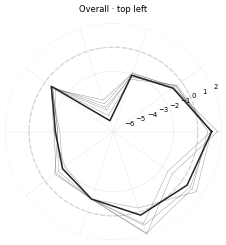

  Saved: spider_overall_top_left.pdf


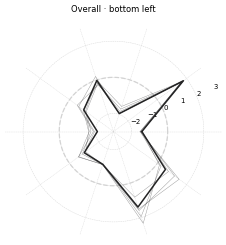

  Saved: spider_overall_bottom_left.pdf


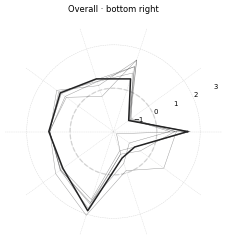

  Saved: spider_overall_bottom_right.pdf


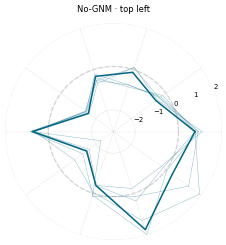

  Saved: spider_no_gnm_top_left.pdf


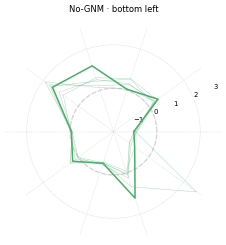

  Saved: spider_no_gnm_bottom_left.pdf


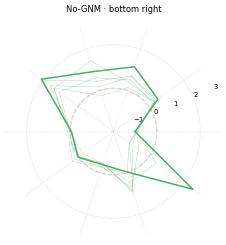

  Saved: spider_no_gnm_bottom_right.pdf


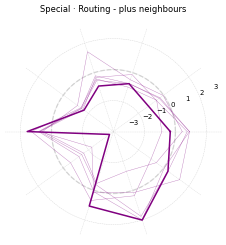

  Saved: spider_special_routing.pdf


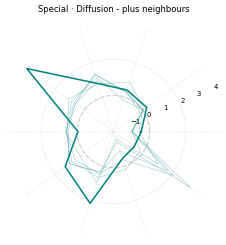

  Saved: spider_special_diffusion.pdf


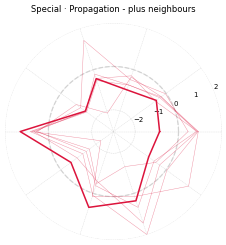

  Saved: spider_special_propagation.pdf


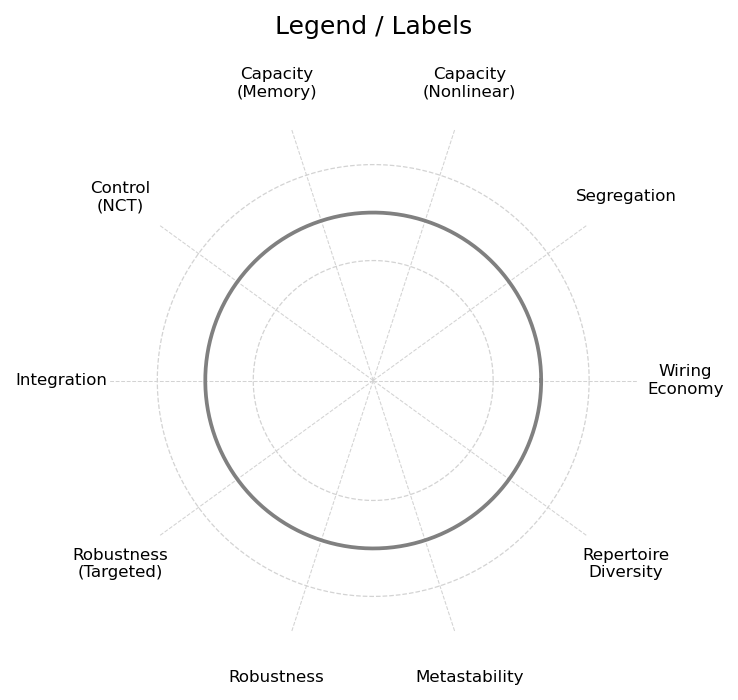

  Saved: spider_labels_only.pdf
/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/pca_results/spider_special_propagation.pdf


In [263]:

# ── Rebuild panels list with neighbour data ───────────────────────────────────

panels = []

# First 6: Overall and No-GNM corners
for corner_name, orig_idx in corners_full.items():
    ds    = sel_df_label["dataset"].iloc[orig_idx]
    color = COLOR_SCHEME[ds]
    nb_idx = get_neighbours(orig_idx, sel_pca_result, n=5)
    nb_vals = [sel_scaled[i, rep_idx] for i in nb_idx]
    panels.append((
        f"Overall · {corner_name.replace('_', ' ')}",
        sel_scaled[orig_idx, rep_idx], color,
        f"spider_overall_{corner_name}.pdf",
        nb_vals,
    ))

for corner_name, orig_idx in corners_no_gnm.items():
    ds    = sel_df_label["dataset"].iloc[orig_idx]
    color = COLOR_SCHEME[ds]
    # Exclude GNM from neighbour search too, since we're in the no-GNM regime
    nb_idx = get_neighbours(orig_idx, sel_pca_result, n=5,
                            exclude_gnm=True, df_label=sel_df_label, gnm_name=GNM_DATASET)
    nb_vals = [sel_scaled[i, rep_idx] for i in nb_idx]
    panels.append((
        f"No-GNM · {corner_name.replace('_', ' ')}",
        sel_scaled[orig_idx, rep_idx], color,
        f"spider_no_gnm_{corner_name}.pdf",
        nb_vals,
    ))

# Last 3: Special datasets
for ds_key, orig_idx in special_indices.items():
    label, color = SPECIAL_DATASETS[ds_key]
    nb_idx = get_neighbours(orig_idx, sel_pca_result, n=5)
    nb_vals = [sel_scaled[i, rep_idx] for i in nb_idx]
    panels.append((
        f"Special · {label} - plus neighbours",
        sel_scaled[orig_idx, rep_idx], color,
        f"spider_special_{label.lower()}.pdf",
        nb_vals,
    ))

# ── Save all 9 plots ──────────────────────────────────────────────────────────

# for title, vals, color, fname, nb_vals in panels:
#     make_spider_standalone(
#         values=vals,
#         label=title,
#         color=color,
#         feature_labels=rep_labels,
#         title=title,
#         ylim=YLIM,
#         filepath=output_folder / fname,
#         neighbour_vals_list=nb_vals,
#     )
for title, vals, color, fname, nb_vals in panels:
    make_spider_standalone(
        values=vals,
        label=title,
        color=color,
        feature_labels=rep_labels,
        title=title,
        filepath=output_folder / fname,
        neighbour_vals_list=nb_vals,
    )
# ── Label-only plot (unchanged) ───────────────────────────────────────────────

make_legend_plot(rep_labels, angles_for_legend, filepath=output_folder / "spider_labels_only.pdf")

print(output_folder / fname)

# With arches above each of the categories

In [264]:
# # ── Grouped axis pairs: (label_a, label_b, group_color) ──────────────────────
# AXIS_GROUPS = [
#     ("Capacity\n(Nonlinear)", "Capacity\n(Memory)",     half_black), # "#E07B39"),  # orange
#     ("Robustness\n(Targeted)", "Robustness",              half_black),  # "#5B8DB8"),  # blue
#     ("Metastability",          "Repertoire\nDiversity",   half_black),  # "#6AAB6A"),  # green
# ]

# def draw_axis_group_arcs(ax, feature_labels, angles, arc_radius, groups):
#     """
#     Draw a bold arc just outside the plot connecting paired spokes.
#     arc_radius: draw the arc at this r value (slightly beyond local_max).
#     """
#     theta_dense = np.linspace(0, 2 * np.pi, 1000)

#     for label_a, label_b, color in groups:
#         if label_a not in feature_labels or label_b not in feature_labels:
#             continue
#         i_a = feature_labels.index(label_a)
#         i_b = feature_labels.index(label_b)

#         angle_a = angles[i_a]
#         angle_b = angles[i_b]

#         # Always sweep the short way between the two spokes
#         if angle_b < angle_a:
#             angle_a, angle_b = angle_b, angle_a

#         # Choose the shorter arc
#         if angle_b - angle_a > np.pi:
#             arc_angles = np.linspace(angle_b, angle_a + 2 * np.pi, 80)
#         else:
#             arc_angles = np.linspace(angle_a, angle_b, 80)

#         arc_r = np.full_like(arc_angles, arc_radius)

#         ax.plot(arc_angles, arc_r,
#                 color=color, linewidth=3.5, solid_capstyle="round",
#                 zorder=6, alpha=0.85)

#         # Small dots at each endpoint to cap the arc neatly
#         ax.scatter([arc_angles[0], arc_angles[-1]],
#                    [arc_radius, arc_radius],
#                    color=color, s=18, zorder=7, alpha=0.85)


# def make_spider_standalone(values, label, color, feature_labels, title,
#                            filepath, neighbour_vals_list=None):
#     n = len(values)
#     angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
#     angles_closed = angles + angles[:1]
#     vals_closed   = list(values) + [values[0]]

#     fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True), dpi=50)

#     # ── Auto-scale ──
#     all_plot_vals = list(values)
#     if neighbour_vals_list is not None:
#         for nb in neighbour_vals_list:
#             all_plot_vals.extend(nb)
#     local_min = np.floor(min(all_plot_vals))
#     local_max = np.ceil(max(all_plot_vals))
#     ax.set_ylim(local_min, local_max)

#     ax.spines["polar"].set_visible(False)
#     ax.yaxis.grid(False)
#     ax.xaxis.grid(False)

#     theta_ring = np.linspace(0, 2 * np.pi, 300)

#     for r_val in RING_VALS:
#         ax.plot(theta_ring, np.full(300, r_val),
#                 color="lightgray", linewidth=0.6, linestyle="--", zorder=0)
#     ax.plot(theta_ring, np.zeros(300),
#             color="gray", linewidth=1.8, linestyle="-", zorder=1)
#     for angle in angles:
#         ax.plot([angle, angle], [local_min, local_max],
#                 color="lightgray", linewidth=0.5, linestyle="--", zorder=0)

#     if neighbour_vals_list is not None:
#         for nb_vals in neighbour_vals_list:
#             nb_closed = list(nb_vals) + [nb_vals[0]]
#             ax.plot(angles_closed, nb_closed,
#                     color=color, linewidth=0.6, alpha=0.25, zorder=3)
#             ax.fill(angles_closed, nb_closed,
#                     color=color, alpha=0.04, zorder=2)

#     ax.plot(angles_closed, vals_closed, color=color, linewidth=2.2, zorder=5)
#     ax.fill(angles_closed, vals_closed, color=color, alpha=0.20, zorder=4)

#     # ── Group arcs just outside the outermost ring ──
#     arc_r = local_max + (local_max - local_min) * 0.12
#     draw_axis_group_arcs(ax, list(feature_labels), angles, arc_r, AXIS_GROUPS)
#     # Expand ylim slightly so the arc isn't clipped
#     ax.set_ylim(local_min, arc_r + (local_max - local_min) * 0.05)

#     ax.set_thetagrids([])
#     ax.set_xticklabels([])
#     ax.set_title(title) # , pad=16)

#     plt.tight_layout()
#     plt.savefig(filepath, dpi=150, bbox_inches="tight")
#     plt.show()
#     plt.close(fig)
#     print(f"  Saved: {filepath.name}")

In [265]:
# def make_legend_plot(feature_labels, angles, filepath):
#     n = len(feature_labels)
#     angles_plot = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()

#     fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True), dpi=150)
#     ax.set_ylim(YLIM[0], YLIM[1] * 1.2)
#     ax.set_yticks([])
#     ax.spines["polar"].set_visible(False)
#     ax.yaxis.grid(False)
#     ax.xaxis.grid(False)

#     for angle in angles_plot:
#         ax.plot([angle, angle], [YLIM[0], YLIM[1]],
#                 color="lightgray", linewidth=0.5, linestyle="--", zorder=0)
#     theta_ring = np.linspace(0, 2 * np.pi, 300)
#     ax.plot(theta_ring, np.zeros(300), color="gray", linewidth=1.8, zorder=1)
#     for r_val in RING_VALS:
#         ax.plot(theta_ring, np.full(300, r_val),
#                 color="lightgray", linewidth=0.6, linestyle="--", zorder=0)

#     arc_r = YLIM[1] + (YLIM[1] - YLIM[0]) * 0.12
#     draw_axis_group_arcs(ax, list(feature_labels), angles_plot, arc_r, AXIS_GROUPS)

#     ax.set_thetagrids(np.degrees(angles_plot), feature_labels, fontsize=8)
#     ax.set_title("Legend / Labels", pad=16)
#     plt.tight_layout()
#     plt.savefig(filepath, dpi=150, bbox_inches="tight")
#     plt.show()
#     plt.close(fig)
#     print(f"  Saved: {filepath.name}")

In [266]:

# # ── Rebuild panels list with neighbour data ───────────────────────────────────

# panels = []

# # First 6: Overall and No-GNM corners
# for corner_name, orig_idx in corners_full.items():
#     ds    = sel_df_label["dataset"].iloc[orig_idx]
#     color = COLOR_SCHEME[ds]
#     nb_idx = get_neighbours(orig_idx, sel_pca_result, n=5)
#     nb_vals = [sel_scaled[i, rep_idx] for i in nb_idx]
#     panels.append((
#         f"Overall · {corner_name.replace('_', ' ')}",
#         sel_scaled[orig_idx, rep_idx], color,
#         f"spider_overall_{corner_name}.pdf",
#         nb_vals,
#     ))

# for corner_name, orig_idx in corners_no_gnm.items():
#     ds    = sel_df_label["dataset"].iloc[orig_idx]
#     color = COLOR_SCHEME[ds]
#     # Exclude GNM from neighbour search too, since we're in the no-GNM regime
#     nb_idx = get_neighbours(orig_idx, sel_pca_result, n=5,
#                             exclude_gnm=True, df_label=sel_df_label, gnm_name=GNM_DATASET)
#     nb_vals = [sel_scaled[i, rep_idx] for i in nb_idx]
#     panels.append((
#         f"No-GNM · {corner_name.replace('_', ' ')}",
#         sel_scaled[orig_idx, rep_idx], color,
#         f"spider_no_gnm_{corner_name}.pdf",
#         nb_vals,
#     ))

# # Last 3: Special datasets
# for ds_key, orig_idx in special_indices.items():
#     label, color = SPECIAL_DATASETS[ds_key]
#     nb_idx = get_neighbours(orig_idx, sel_pca_result, n=5)
#     nb_vals = [sel_scaled[i, rep_idx] for i in nb_idx]
#     panels.append((
#         f"Special · {label} - plus neighbours",
#         sel_scaled[orig_idx, rep_idx], color,
#         f"spider_special_{label.lower()}.pdf",
#         nb_vals,
#     ))

# # ── Save all 9 plots ──────────────────────────────────────────────────────────

# # for title, vals, color, fname, nb_vals in panels:
# #     make_spider_standalone(
# #         values=vals,
# #         label=title,
# #         color=color,
# #         feature_labels=rep_labels,
# #         title=title,
# #         ylim=YLIM,
# #         filepath=output_folder / fname,
# #         neighbour_vals_list=nb_vals,
# #     )
# for title, vals, color, fname, nb_vals in panels:
#     make_spider_standalone(
#         values=vals,
#         label=title,
#         color=color,
#         feature_labels=rep_labels,
#         title=title,
#         filepath=output_folder / fname,
#         neighbour_vals_list=nb_vals,
#     )
# # ── Label-only plot (unchanged) ───────────────────────────────────────────────

# make_legend_plot(rep_labels, angles_for_legend, filepath=output_folder / "spider_labels_only.pdf")

# print(output_folder / fname)

# Taxonomies 

In [330]:
# Taxonomies 
info_mami = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/04_further_info/names_of_animals_with_preprocessed_connectomes_50_processed_removed_95.csv")
taxonomy = "order" # phylogenetic_group" # "order" 

GROUPS_TO_INCLUDE = [
                    'Primates',
                    'Rodentia',
                    # 'Hyracoidea',
                    'Carnivora',
                    # 'Perissodactyla',
                    # 'Chiroptera',
                    'Cetartiodactyla',
                    # 'Eulipotyphla',
                    # 'Scandentia',
                    # 'Xenarthra',
                    # 'Lagomorpha',
                    # 'Marsupialia'
                ]
# info_mami = info_mami[info_mami[taxonomy].isin(GROUPS_TO_INCLUDE)]

# info_mami["tax_color"] = info_mami[taxonomy].astype("category").cat.codes

df_mami = pd.concat([sel_df_label[sel_df_label["dataset"] == "suarez_MaMI_dataset"].reset_index(), info_mami], axis=1) # , left_index=True, right_on=True) # "animal_name")

names = df_mami[taxonomy].unique() # ["tax_color"]
color_map = plt.cm.get_cmap("tab20", len(names)) # "RdYlGn_r", len(names))
color_dict = {name: color_map(i) for i, name in enumerate(names)}

df_mami["tax_color"] = df_mami[taxonomy].map(color_dict)

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_60904/474977728.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab20", len(names)) # "RdYlGn_r", len(names))


In [307]:
# # minimum_df = minimum_df[minimum_df[taxonomy].isin(GROUPS_TO_INCLUDE)]
# # print(minimum_df[taxonomy].unique())

# names = minimum_df[taxonomy].unique() # ["tax_color"]
# color_map = plt.cm.get_cmap("RdYlGn_r", len(names))
# color_dict = {name: color_map(i) for i, name in enumerate(names)}

In [ ]:
# sel_pca_result[sel_df_label["dataset"] == "suarez_MaMI_dataset"]
# sel_df_label[sel_df_label["dataset"] == "suarez_MaMI_dataset"].reset_index()

In [308]:
# plt.scatter(sel_pca_result[sel_df_label["dataset"] == "suarez_MaMI_dataset", 0], 
#             sel_pca_result[sel_df_label["dataset"] == "suarez_MaMI_dataset", 1])  # sel_pca_result[orig_idx, 1],

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_60904/4282740478.py:9: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter([], [], # c=color, # alpha=0.3 # , s=unique_scatters[0],


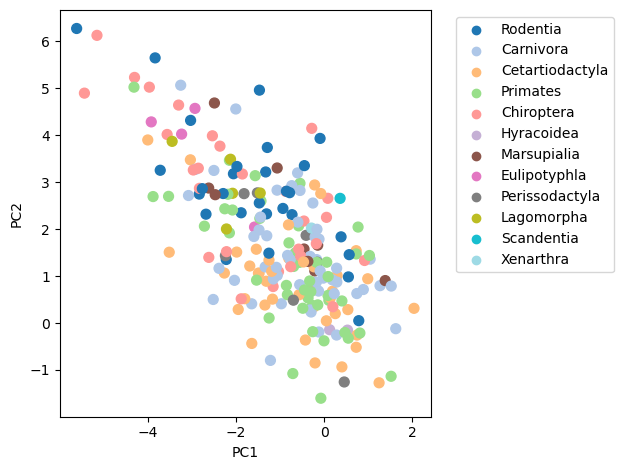

In [ ]:
plt.scatter(sel_pca_result[sel_df_label["dataset"] == "suarez_MaMI_dataset", 0], 
            sel_pca_result[sel_df_label["dataset"] == "suarez_MaMI_dataset", 1], 
            c=df_mami["tax_color"], 
            s=50)

# Faking the legend
for name in df_mami[taxonomy].unique(): # GROUPS_TO_INCLUDE: # color_dict:
    plt.scatter([], [], # c=color, # alpha=0.3 # , s=unique_scatters[0],
                    c=color_dict[name],
                    label=str(name))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # , fontsize=3, frameon=False, labelspacing=1, title='City Area') phylogenetic_group

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()

In [336]:
# Taxonomies 
info_mami = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/04_further_info/names_of_animals_with_preprocessed_connectomes_50_processed_removed_95.csv")
taxonomy = "order" 

GROUPS_TO_INCLUDE = [
                    'Primates',
                    'Rodentia',
                    # 'Hyracoidea',
                    'Carnivora',
                    # 'Perissodactyla',
                    # 'Chiroptera',
                    'Cetartiodactyla',
                    # 'Eulipotyphla',
                    # 'Scandentia',
                    # 'Xenarthra',
                    # 'Lagomorpha',
                    # 'Marsupialia'
                ]
# info_mami = info_mami[info_mami[taxonomy].isin(GROUPS_TO_INCLUDE)]

# info_mami["tax_color"] = info_mami[taxonomy].astype("category").cat.codes

df_mami = pd.concat([sel_df_label[sel_df_label["dataset"] == "suarez_MaMI_dataset"].reset_index(), info_mami], axis=1) # , left_index=True, right_on=True) # "animal_name")

names = df_mami[taxonomy].unique() # ["tax_color"]
color_map = plt.cm.get_cmap("tab20", len(names)) # "RdYlGn_r", len(names))
color_dict = {name: color_map(i) for i, name in enumerate(names)}

df_mami["tax_color"] = df_mami[taxonomy].map(color_dict)



/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_60904/463988841.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab20", len(names)) # "RdYlGn_r", len(names))


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_60904/1619023084.py:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter([], [], # c=color, # alpha=0.3 # , s=unique_scatters[0],


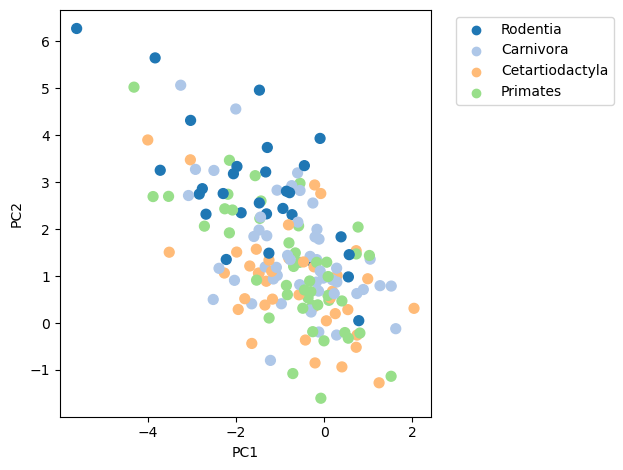

In [340]:
# Only look at specific taxonomies (in GROUPS_TO_INCLUDE) 
mask = df_mami[taxonomy].isin(GROUPS_TO_INCLUDE)

plt.scatter(sel_pca_result[sel_df_label["dataset"] == "suarez_MaMI_dataset", 0][mask], 
            sel_pca_result[sel_df_label["dataset"] == "suarez_MaMI_dataset", 1][mask], 
            c=df_mami[mask]["tax_color"], 
            s=50)

# Faking the legend
for name in df_mami[mask][taxonomy].unique(): # GROUPS_TO_INCLUDE: # color_dict:
    plt.scatter([], [], # c=color, # alpha=0.3 # , s=unique_scatters[0],
                    c=color_dict[name],
                    label=str(name))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # , fontsize=3, frameon=False, labelspacing=1, title='City Area') phylogenetic_group

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()

In [341]:
from sklearn.metrics import pairwise_distances
from scipy.stats import f_oneway
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# ── Extract the relevant PCA coordinates + labels ─────────────────────────────

mami_mask  = (sel_df_label["dataset"] == "suarez_MaMI_dataset").values
tax_mask   = df_mami[taxonomy].isin(GROUPS_TO_INCLUDE).values
combined   = mami_mask.copy()
combined[mami_mask] = tax_mask          # both conditions

X      = sel_pca_result[combined, :2]   # PC1 + PC2 only
labels = df_mami[tax_mask][taxonomy].values

# ── Test 1: PERMANOVA (permutation-based MANOVA on distances) ─────────────────
# "Are the groups more separated than random chance?"

from sklearn.utils import shuffle

def permanova(X, labels, n_permutations=999):
    def f_stat(X, labels):
        groups  = [X[labels == g] for g in np.unique(labels)]
        grand_m = X.mean(axis=0)
        ss_between = sum(len(g) * ((g.mean(0) - grand_m)**2).sum() for g in groups)
        ss_within  = sum(((g - g.mean(0))**2).sum() for g in groups)
        k, n = len(groups), len(X)
        return (ss_between / (k-1)) / (ss_within / (n-k))

    observed = f_stat(X, labels)
    null_dist = [f_stat(X, shuffle(labels)) for _ in range(n_permutations)]
    p = (np.sum(np.array(null_dist) >= observed) + 1) / (n_permutations + 1)
    return observed, p

f_obs, p_perm = permanova(X, labels)
print(f"PERMANOVA  →  F = {f_obs:.3f},  p = {p_perm:.4f}")

# ── Test 2: Per-axis ANOVA ─────────────────────────────────────────────────────
# "Does any single PC axis separate the groups?"

groups_pc1 = [X[labels == g, 0] for g in np.unique(labels)]
groups_pc2 = [X[labels == g, 1] for g in np.unique(labels)]
f1, p1 = f_oneway(*groups_pc1)
f2, p2 = f_oneway(*groups_pc2)
print(f"ANOVA PC1  →  F = {f1:.3f},  p = {p1:.4f}")
print(f"ANOVA PC2  →  F = {f2:.3f},  p = {p2:.4f}")

# ── Test 3: LDA cross-validated accuracy ──────────────────────────────────────
# "Can we predict group membership better than chance?"

from sklearn.model_selection import cross_val_score
lda      = LinearDiscriminantAnalysis()
cv_score = cross_val_score(lda, X, labels, cv=5, scoring="accuracy").mean()
chance   = 1 / len(np.unique(labels))
print(f"LDA 5-fold CV accuracy = {cv_score:.3f}  (chance = {chance:.3f})")

PERMANOVA  →  F = 9.308,  p = 0.0010
ANOVA PC1  →  F = 3.454,  p = 0.0179
ANOVA PC2  →  F = 15.509,  p = 0.0000
LDA 5-fold CV accuracy = 0.326  (chance = 0.250)
